In [33]:
from hossam import load_data, plot
from hossam import prep as hs_prep
import numpy as np

In [34]:
origin=load_data('california_housing')
print('\n===== 데이터 크기 확인 =====')
print(f'데이터셋 크기 : {origin.shape}')
print(f'행 개수 : {origin.shape[0]}개')
print(f'열 개수 : {origin.shape[1]}개')
print('\n===== 타입 확인 =====')
print(origin.info())
origin.head()

[data] https://data.hossam.kr/data/kaggle/california_housing.xlsx
[desc] 1990년 미국 인구조사(Census)를 기반으로 캘리포니아 각 지역의 인구·주택·소득 특성과 주택 중위가격을 담아, 회귀 분석과 머신러닝 모델 실습에 널리 사용되는 대표적인 주택 가격 데이터 (출처: https://www.kaggle.com/datasets/camnugent/california-housing-prices)

field               description
------------------  ------------------------------------------------------------------------------
longitude           경도(Longitude). 서경(–값) 기준.
latitude            위도(Latitude). 북위(+) 기준.
housing_median_age  해당 구역(블록 그룹)의 주택 중위 연령(년).
total_rooms         구역 내 모든 주택의 총 방(room) 수 합계.
total_bedrooms      구역 내 모든 주택의 총 침실(bedroom) 수 합계.
population          구역의 전체 인구 수.
households          구역의 전체 “가구 수”(living units).
median_income       구역의 중위 소득(median income), 단위는 약 1 = $10,000 수준.
median_house_value  주택 중위가격(달러). 회귀의 목표변수(타깃).
ocean_proximity     해안과의 거리/접근성 범주: <1H OCEAN, INLAND, NEAR BAY, NEAR OCEAN, ISLAND 등.


===== 데이터 크기 확인 =====
데이터셋 크기 : (20640, 10)
행 개수 : 20640개
열 개수 : 10개

===== 타입 확인 =====
<c

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41,880,129.0,322,126,8.3252,452600,NEAR BAY
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,358500,NEAR BAY
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,352100,NEAR BAY
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,341300,NEAR BAY
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,342200,NEAR BAY


In [35]:
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

## 🎯미션1. 데이터의 신뢰성 검사 및 전처리

In [36]:
origin.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

total_bedrooms 결측치 어떻게 채우지? <- 고민.... ⭐⭐⭐  
걍 없애기로 결정....!

In [37]:
df=origin.dropna()
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

In [38]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000,20433.000000
mean,-119.570689,35.633221,28.633094,2636.504233,537.870553,1424.946949,499.433465,3.871162,206864.413155
std,2.003578,2.136348,12.591805,2185.269567,421.385070,1133.208490,382.299226,1.899291,115435.667099
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1450.000000,296.000000,787.000000,280.000000,2.563700,119500.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.536500,179700.000000
75%,-118.010000,37.720000,37.000000,3143.000000,647.000000,1722.000000,604.000000,4.744000,264700.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [39]:
df[df['median_house_value']==0].count()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

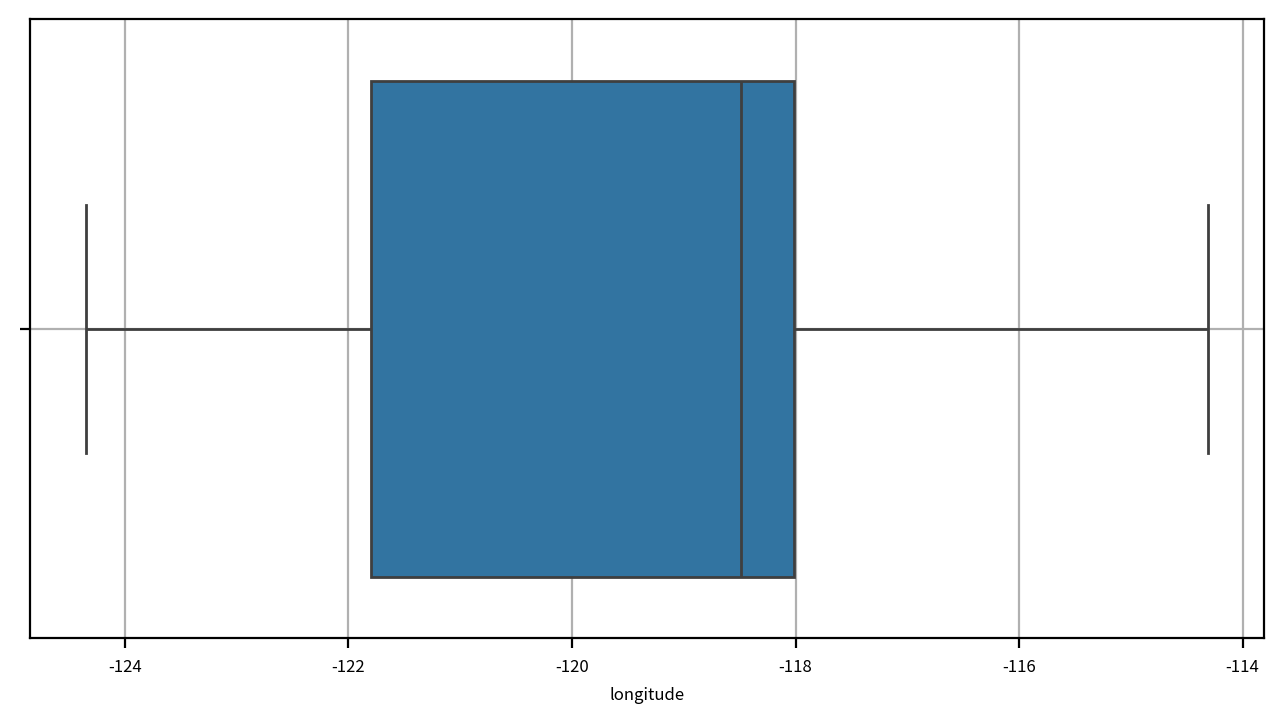

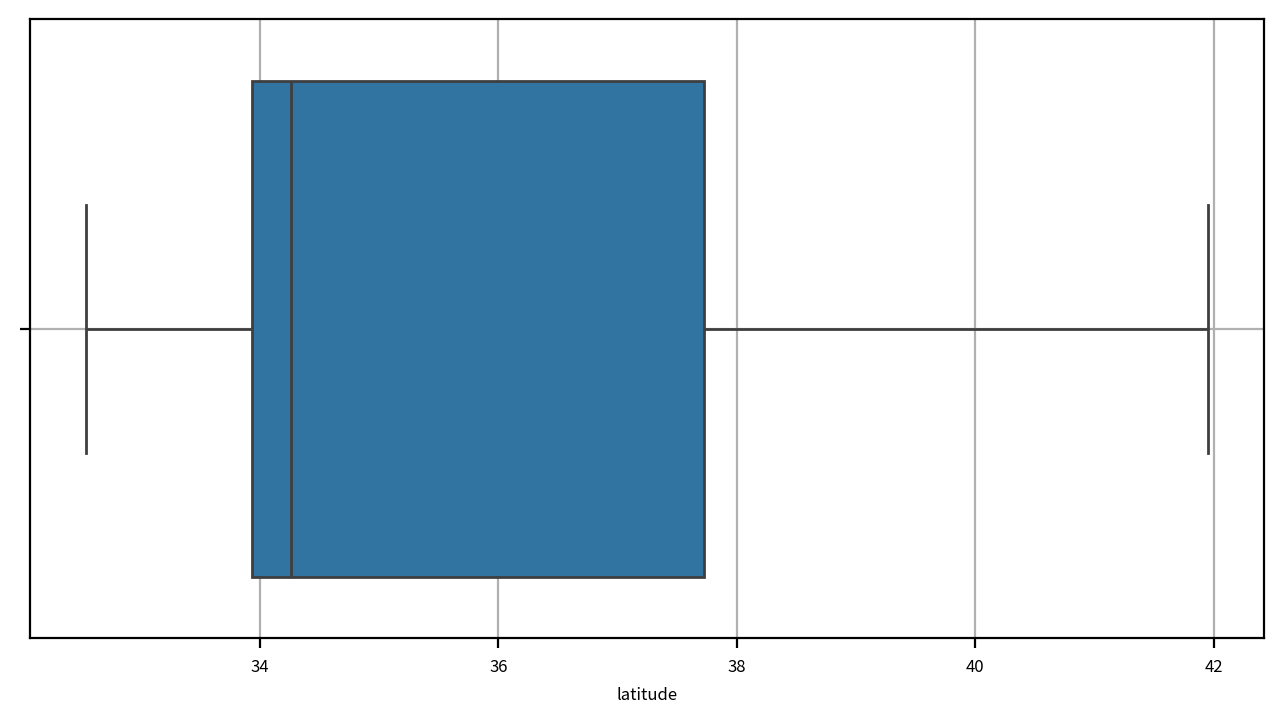

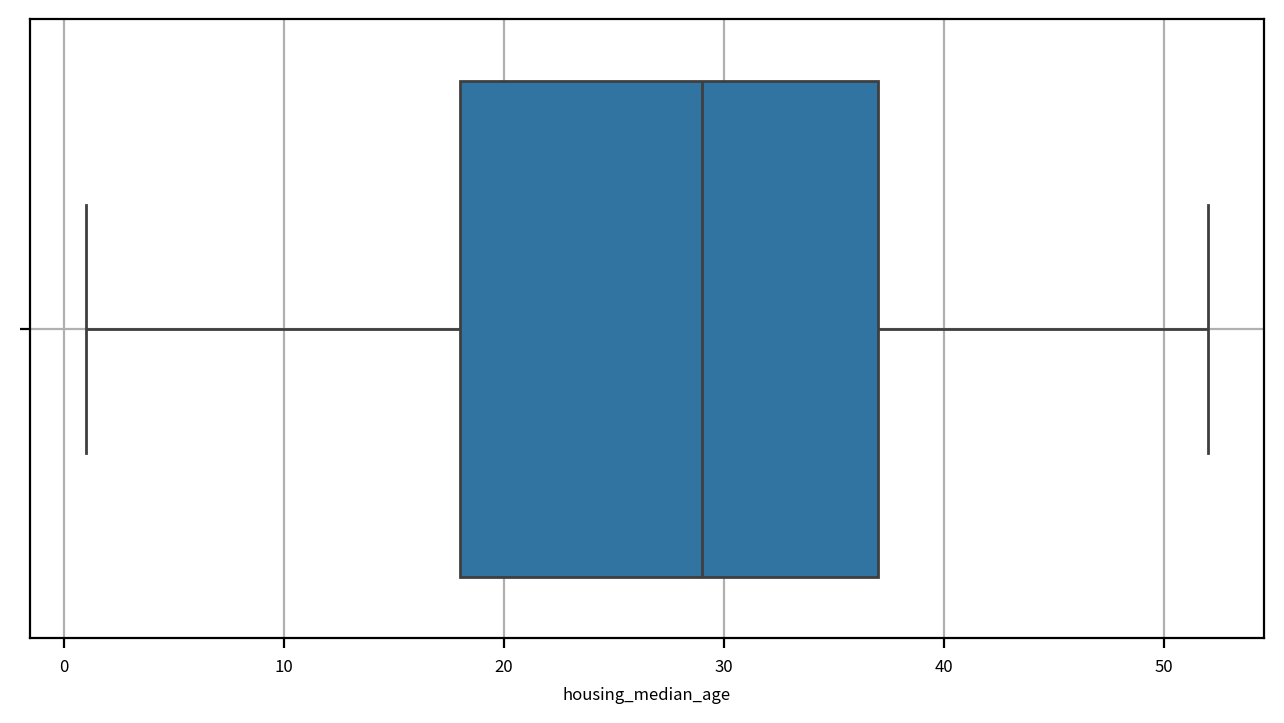

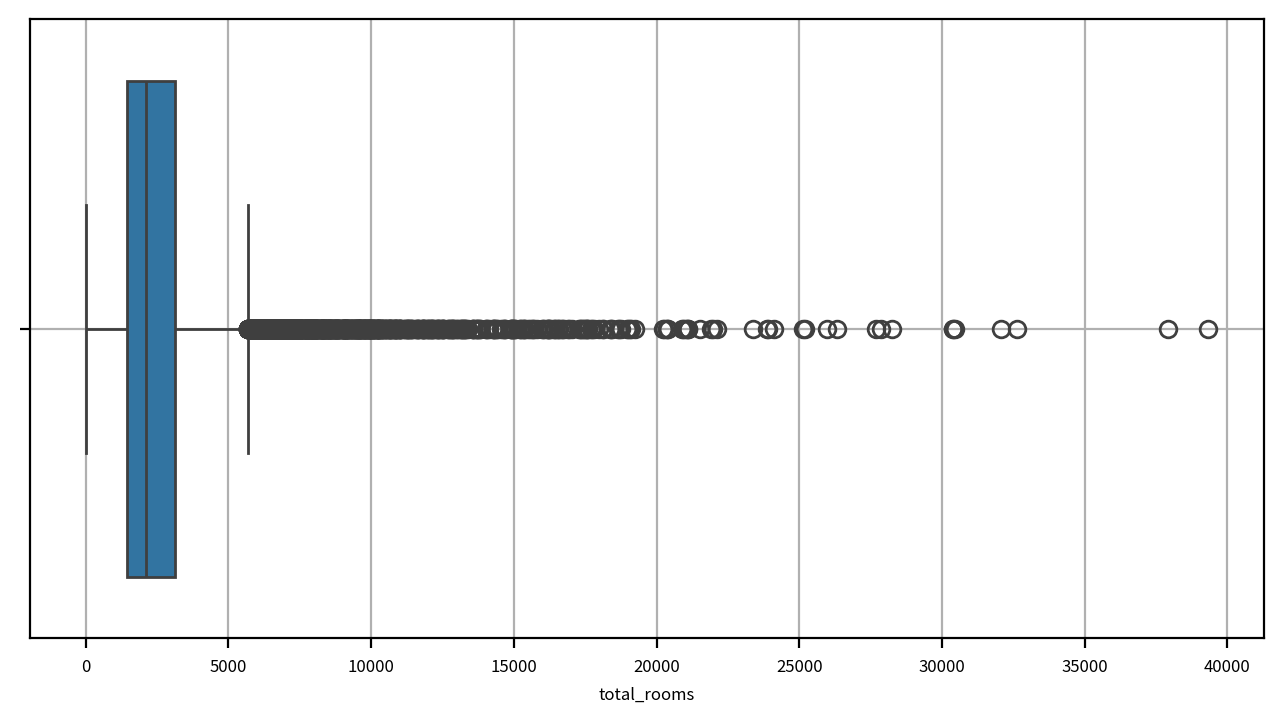

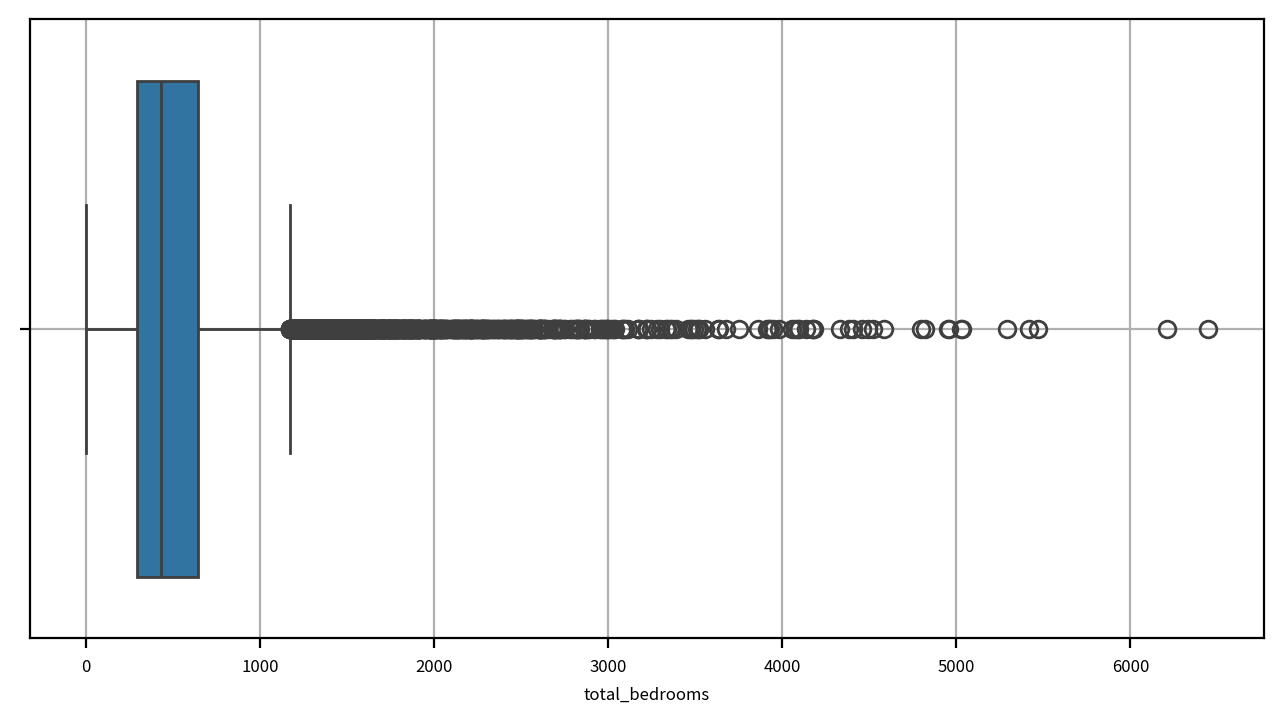

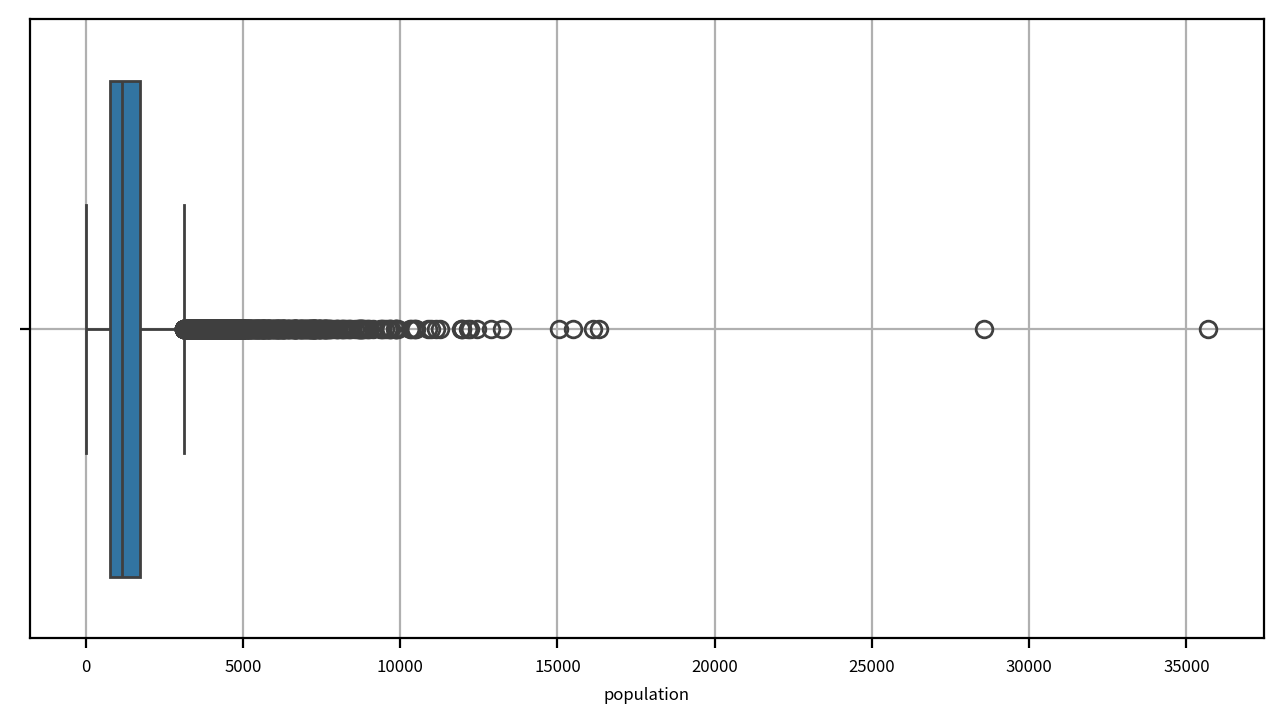

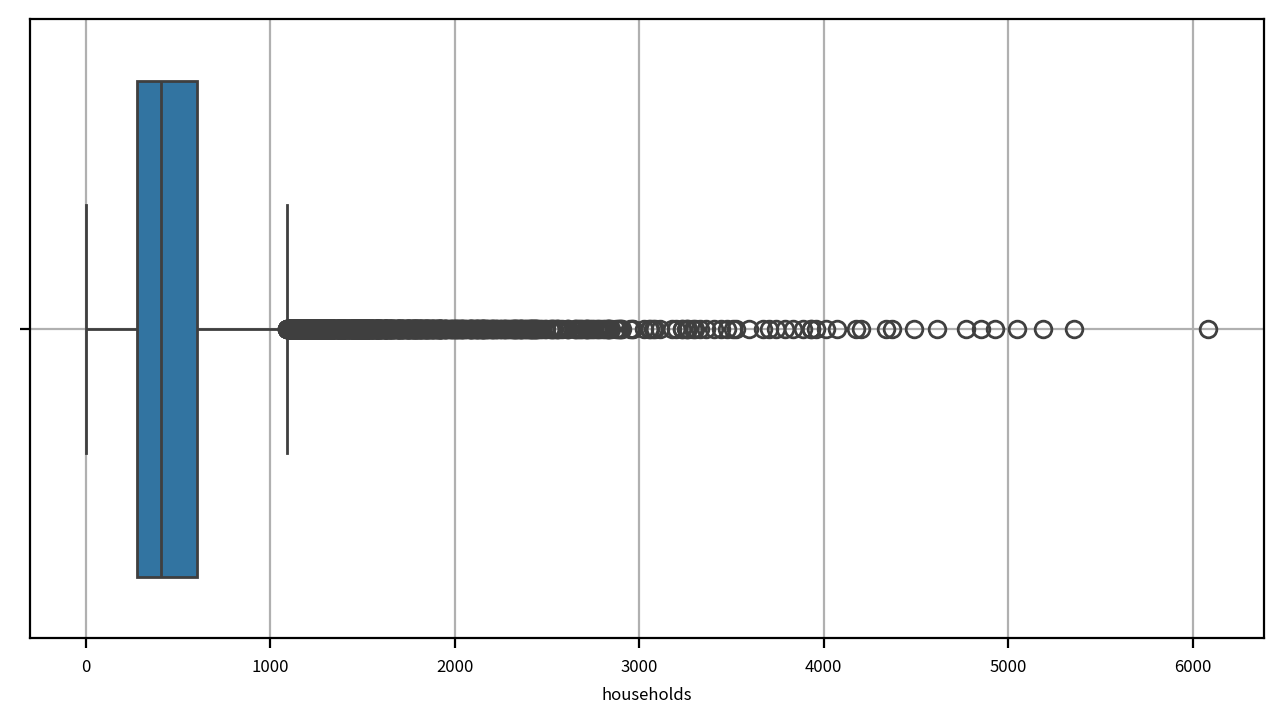

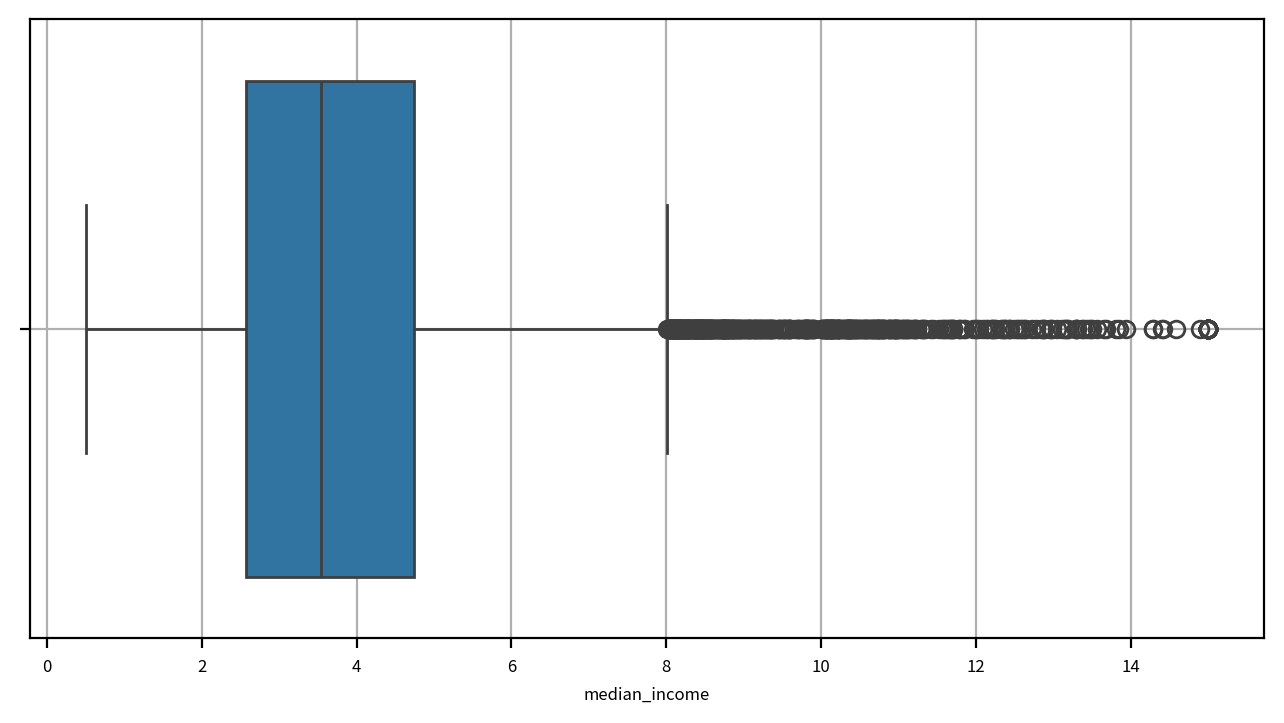

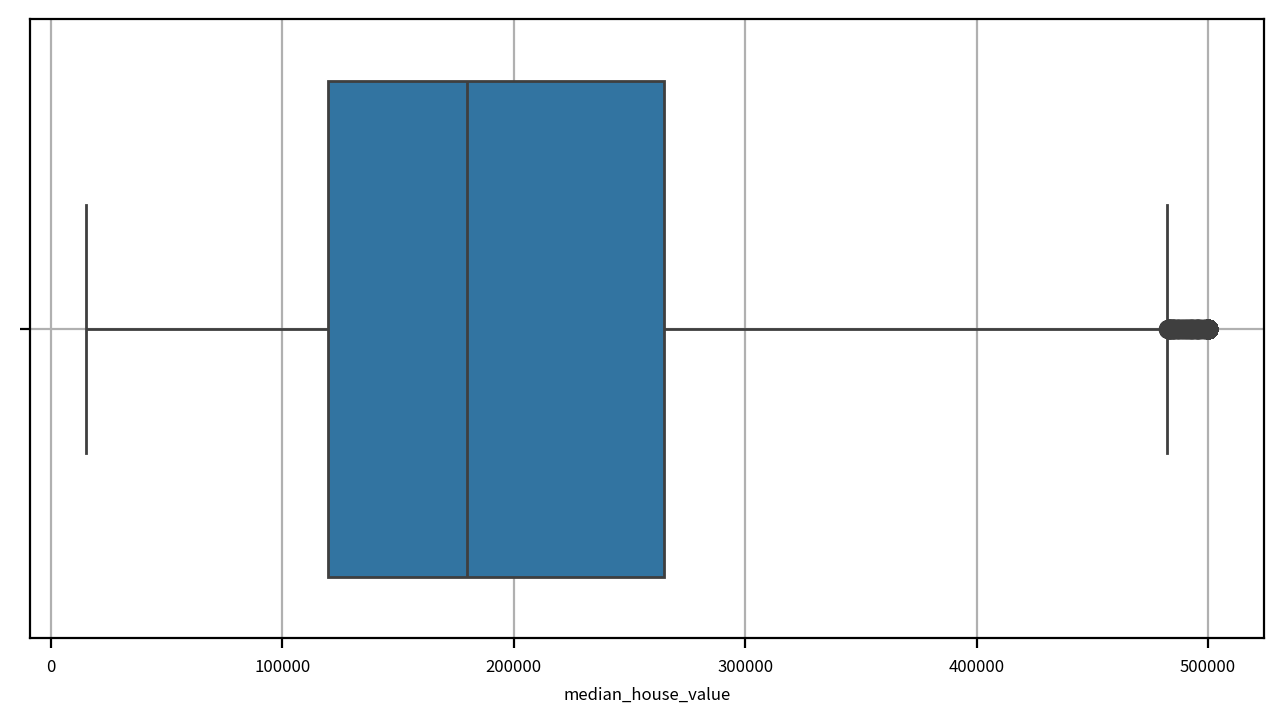

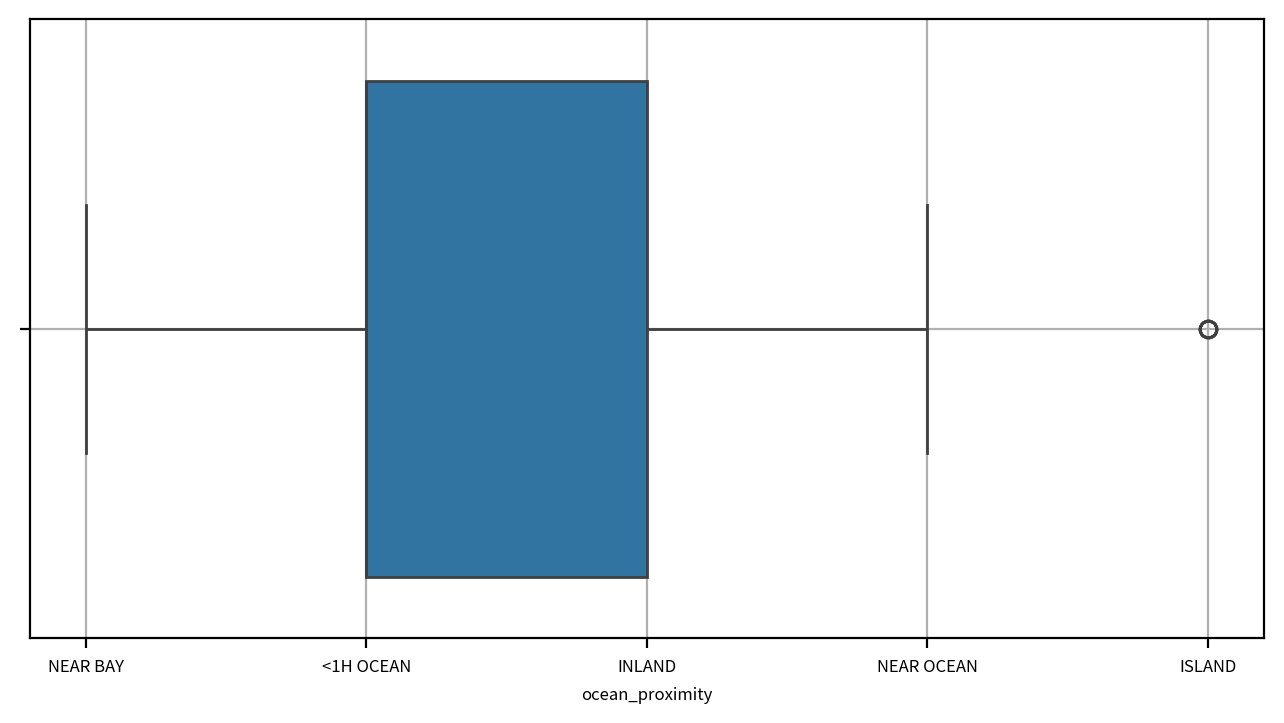

In [40]:
for i in df.columns:
    plot.hs_boxplot(df=df[i], orient='h')

In [41]:
# 인구수 너무 많은 것들 날려버리기
df1=df.drop(index=df[df['population']>14000].index)

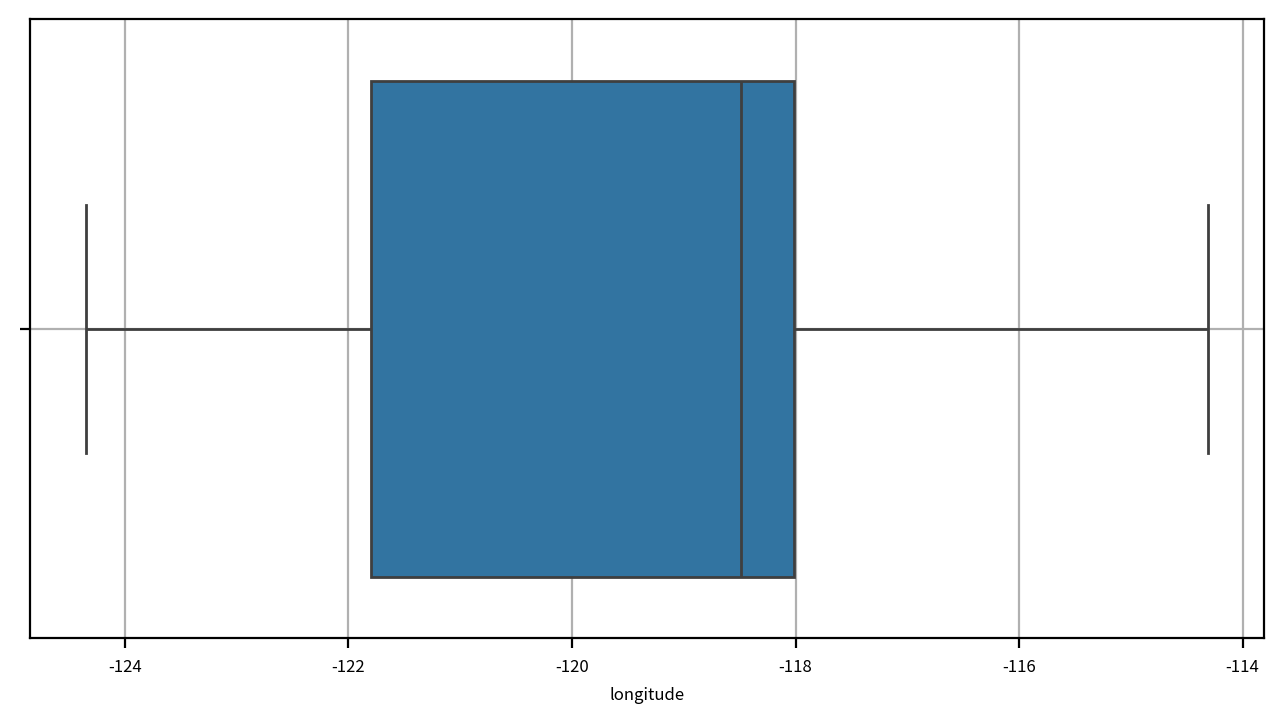

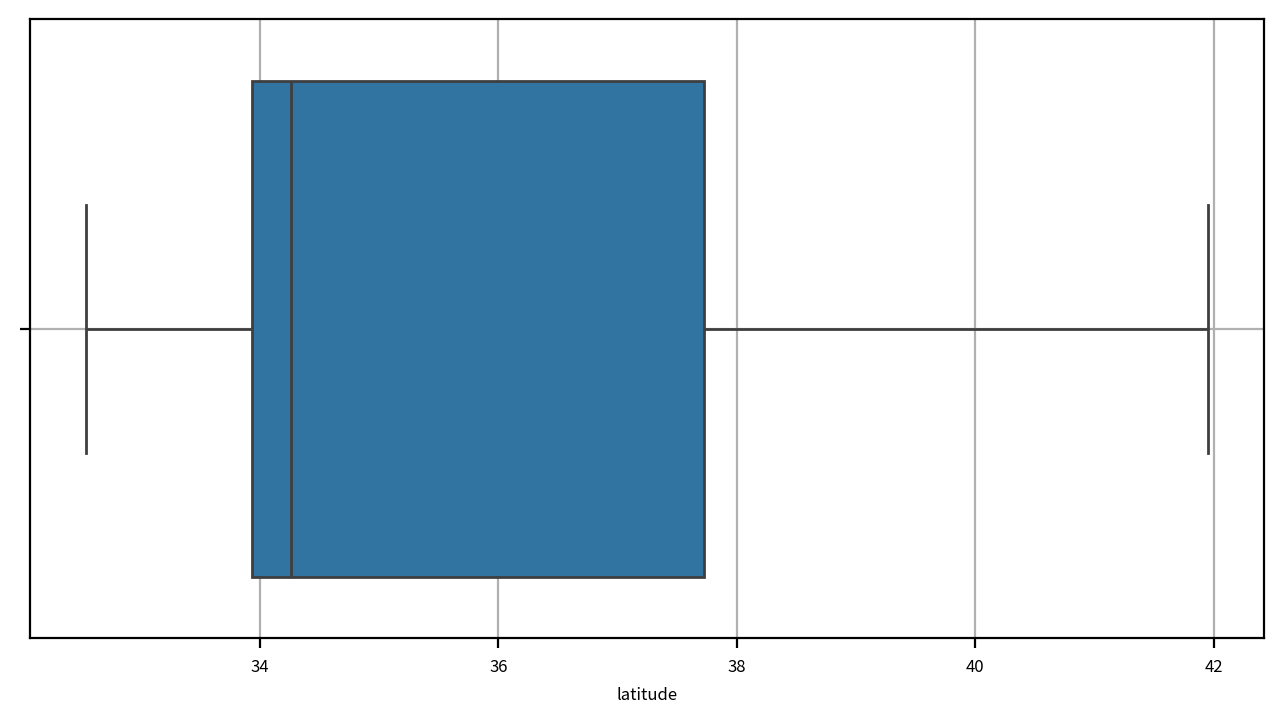

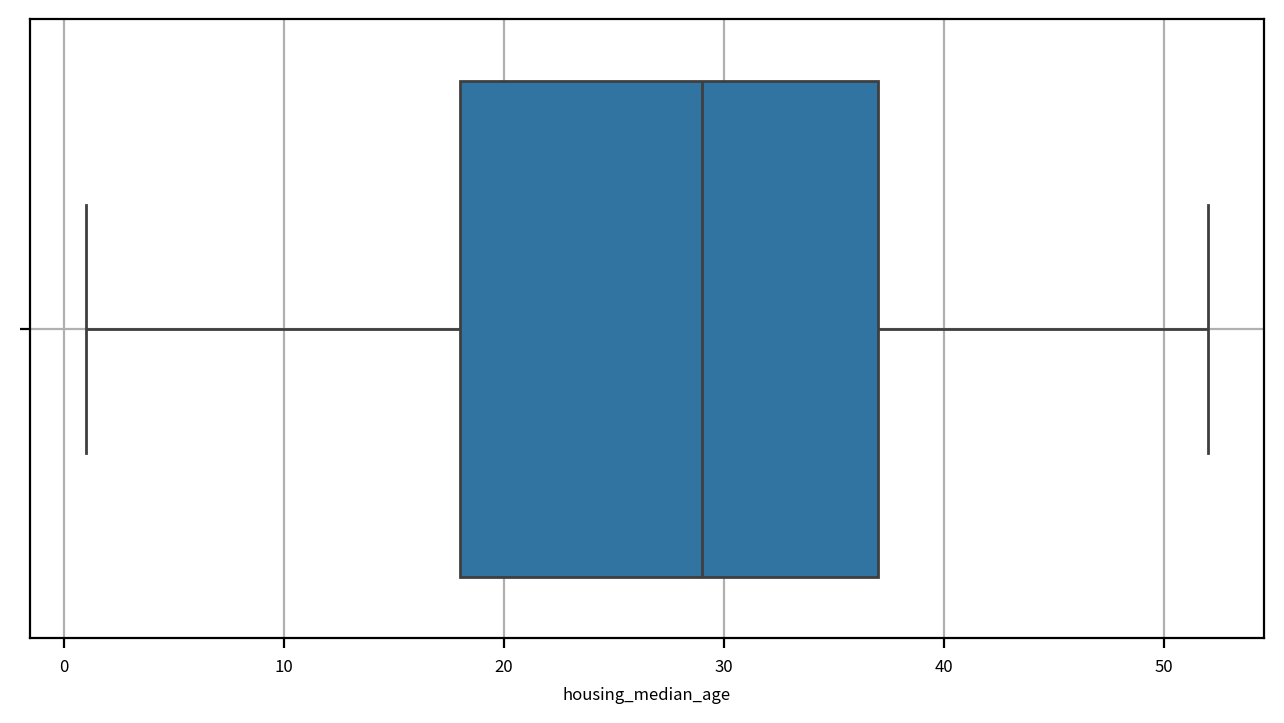

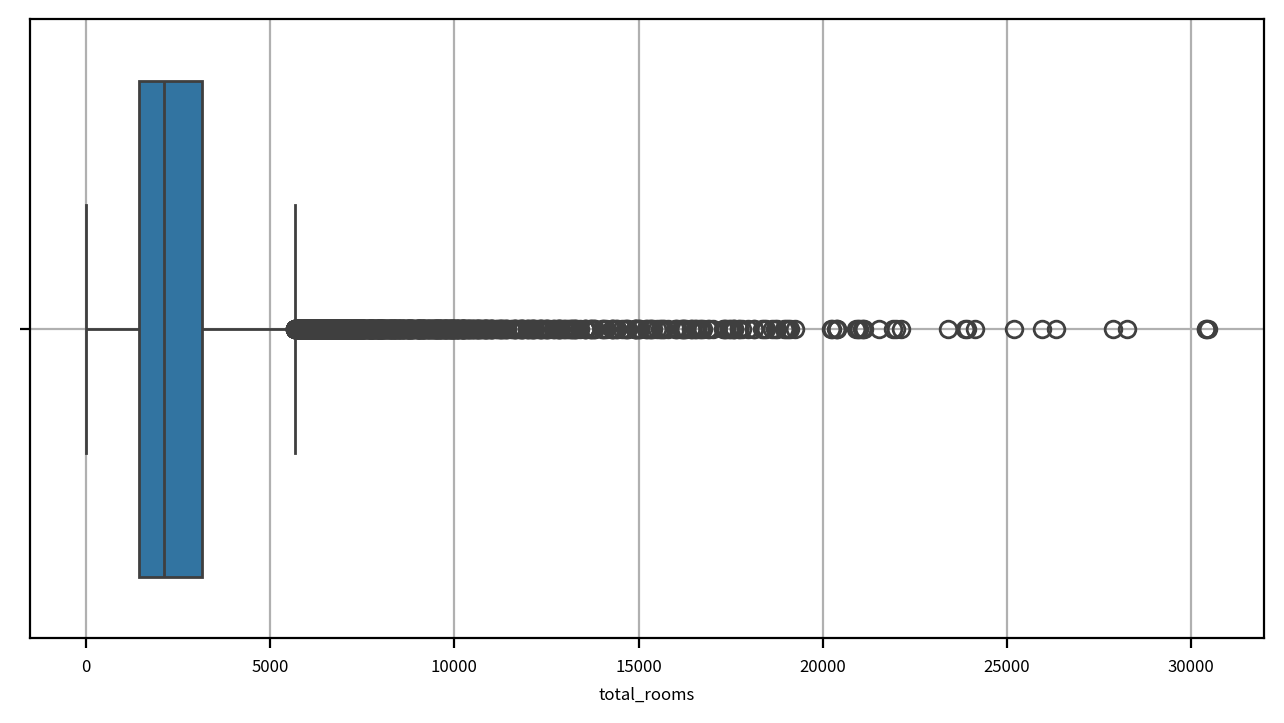

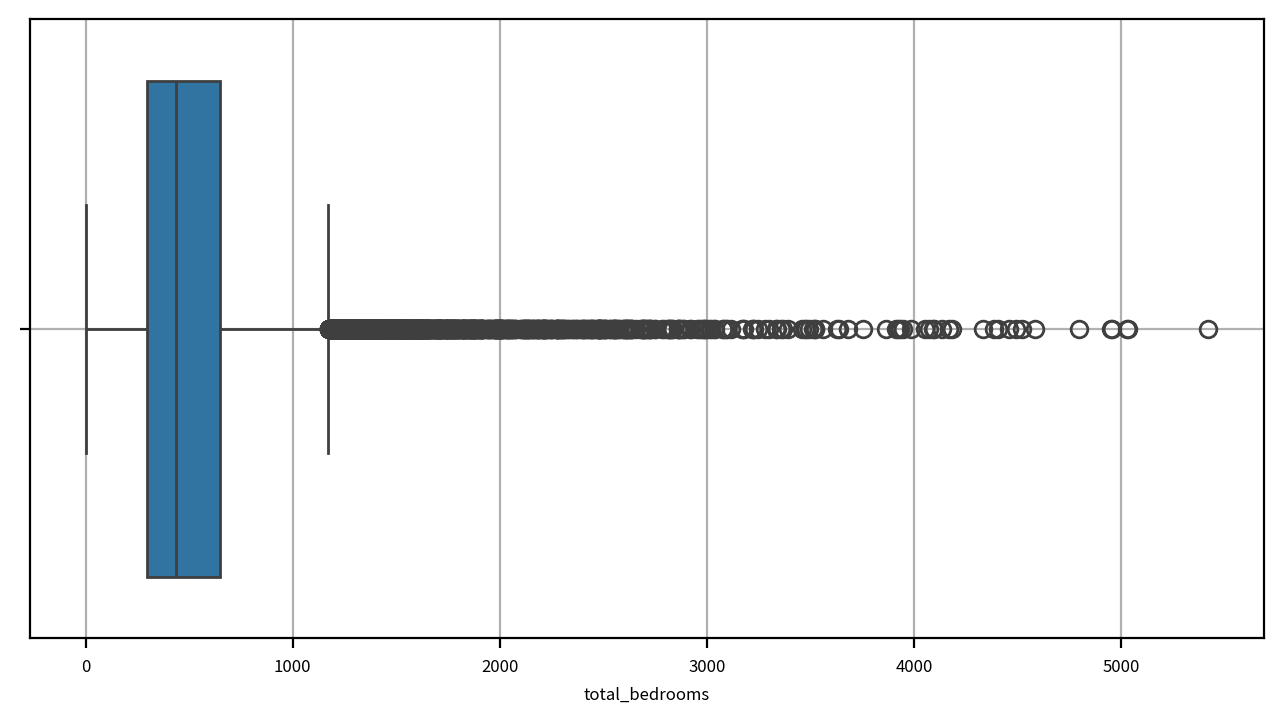

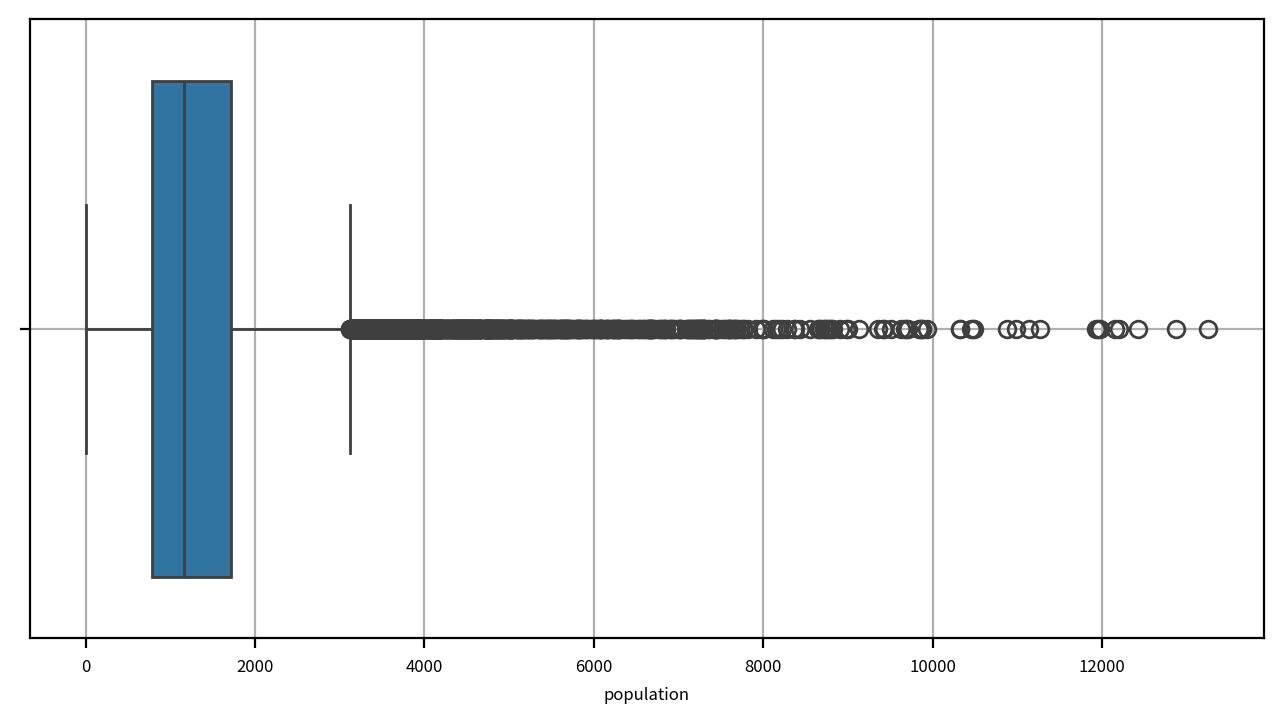

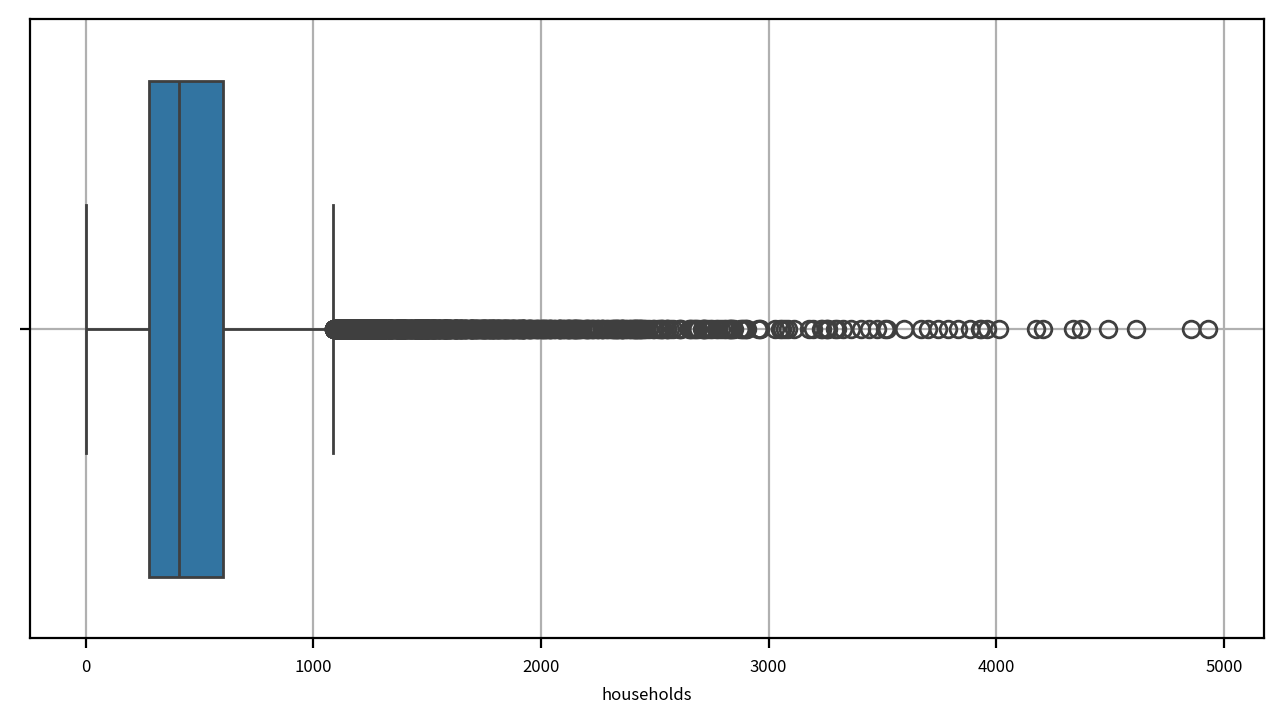

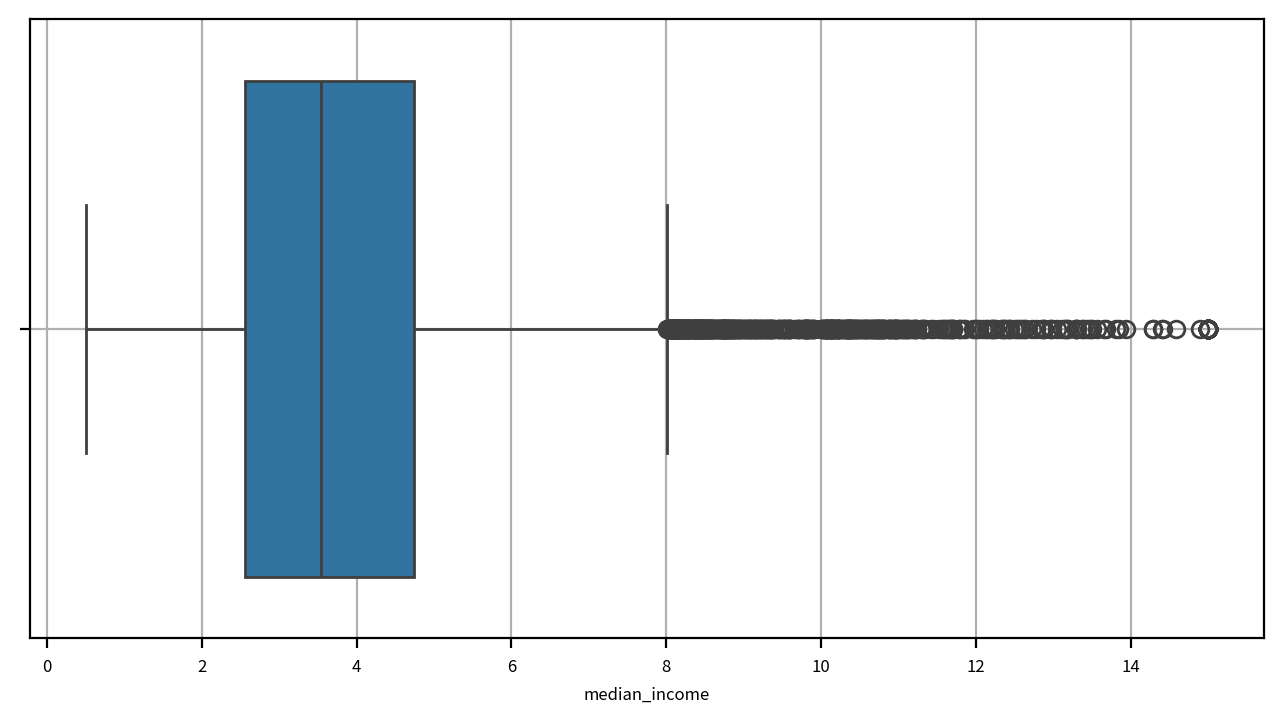

In [42]:
mylist=['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for i in mylist:
    plot.hs_boxplot(df=df1[i], orient='h')

1938년에 미국에서 연방주택저당공사(페니메)가 설립되고 국가 주택법이 개정되면서, 공공주택의 본격적인 건설이 시작되었다.  
따라서 1940년 이전 건축 주택 중위 연령이 52로 1938년에 많은 주택이 지어졌음을 시사하고 있다.  

In [43]:
df2=hs_prep.hs_drop_outliner(data=df1)
df2

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


초고소득층 제거 완료!! 🤮

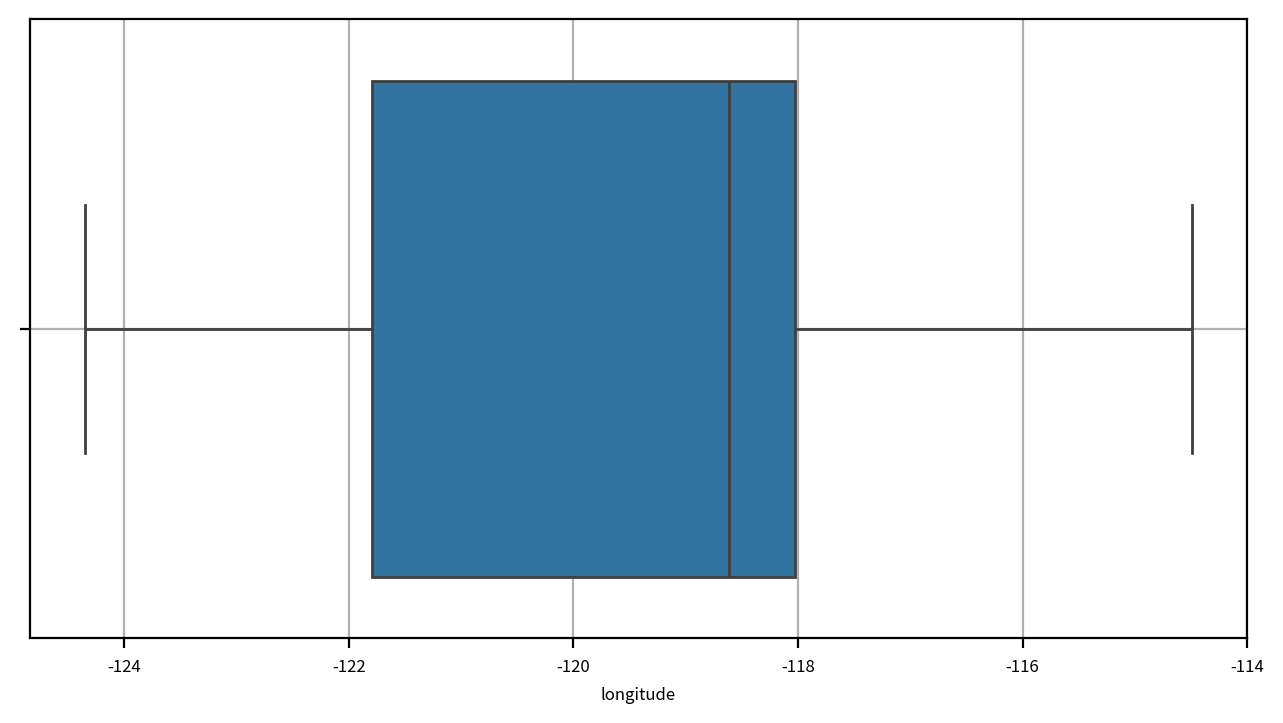

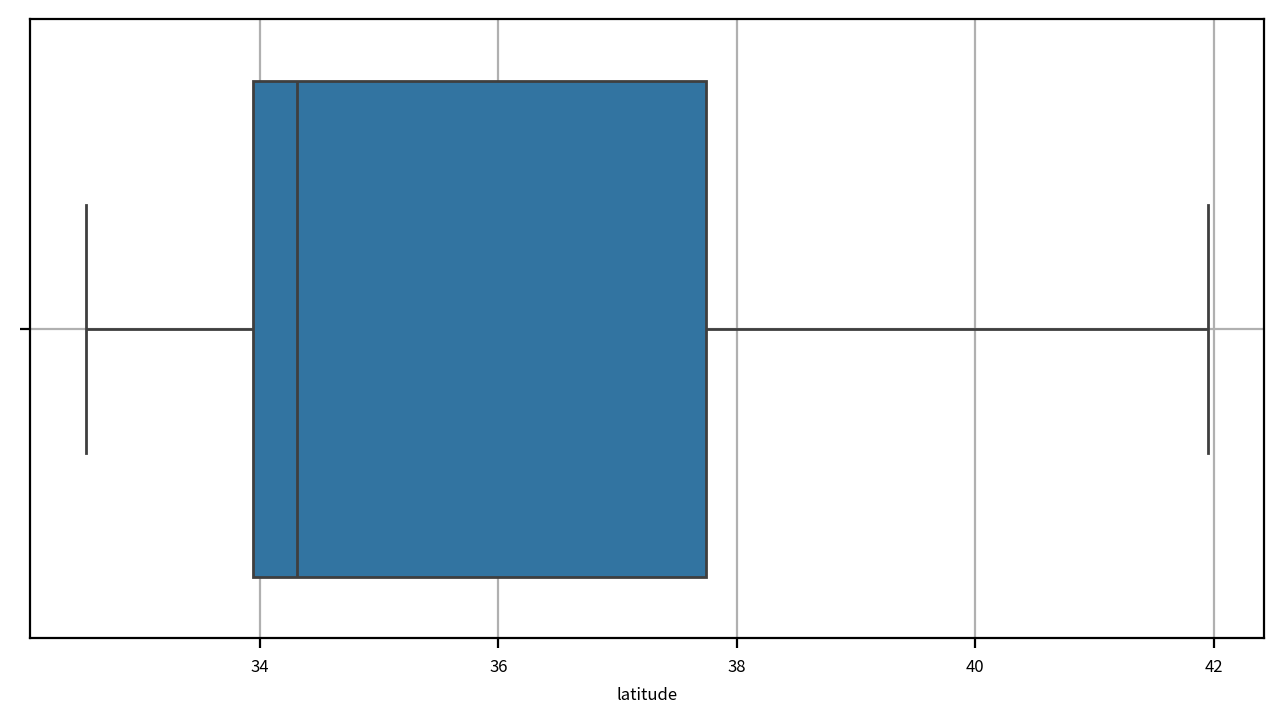

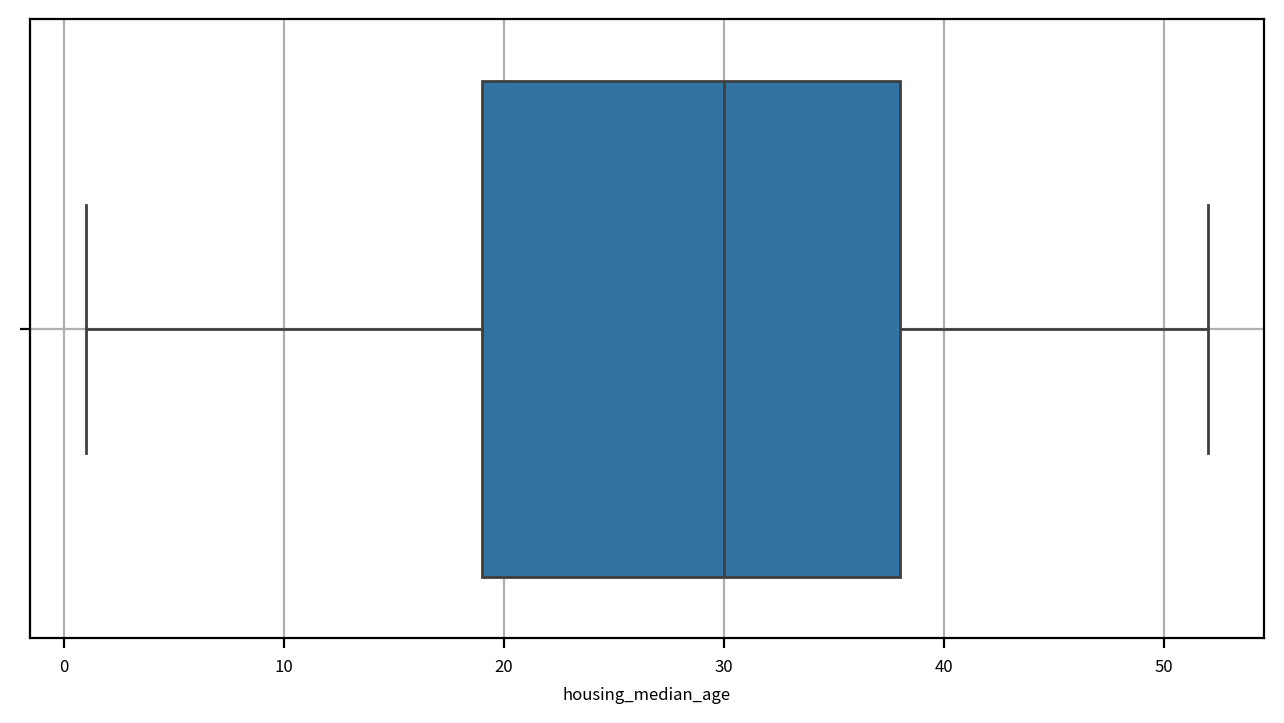

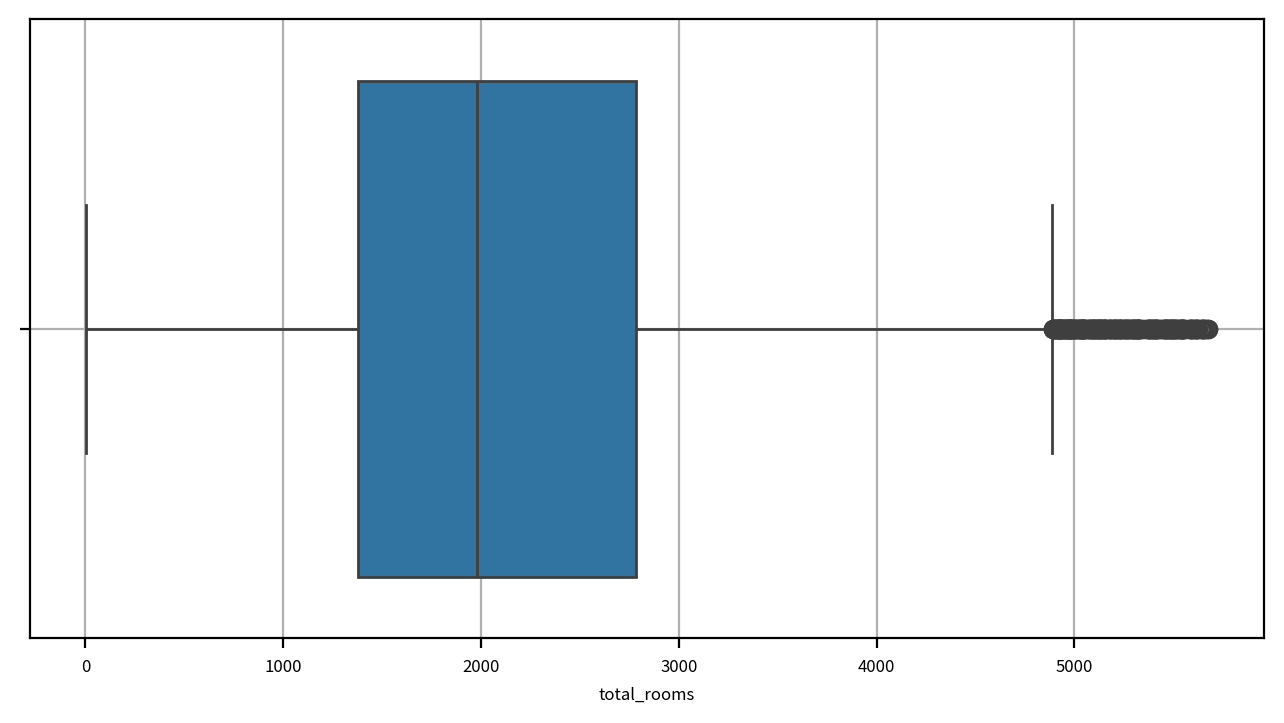

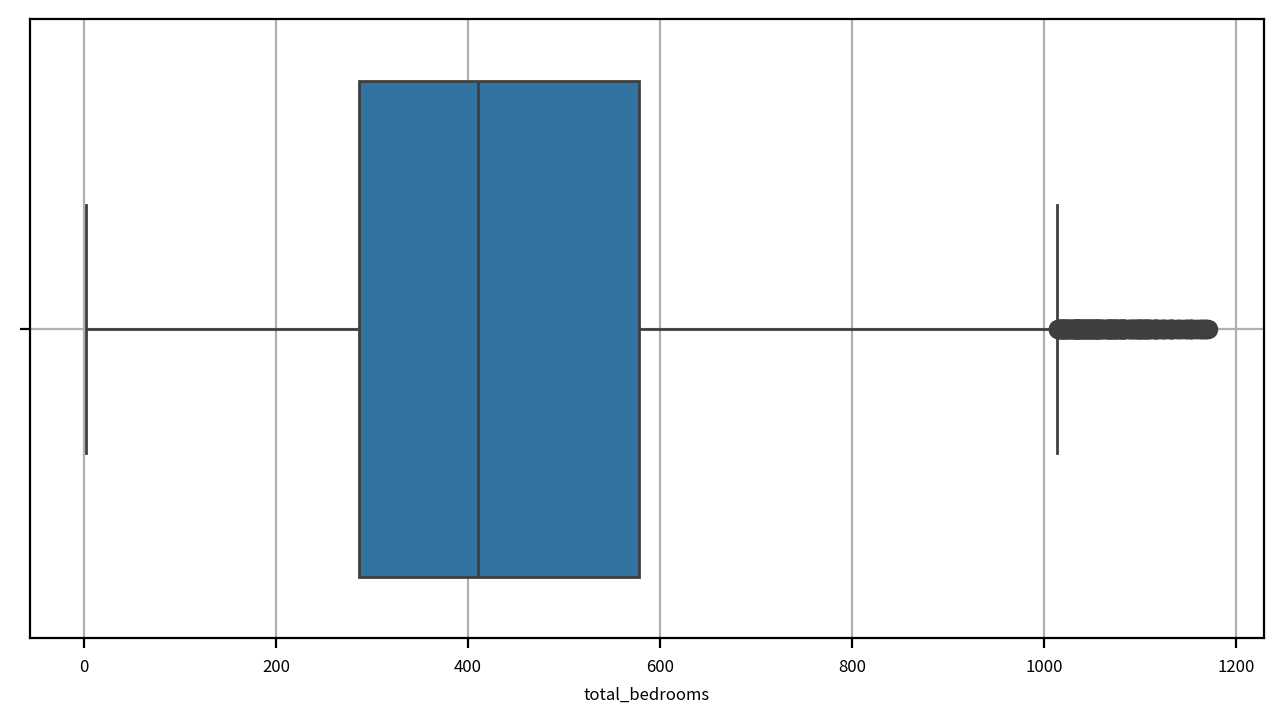

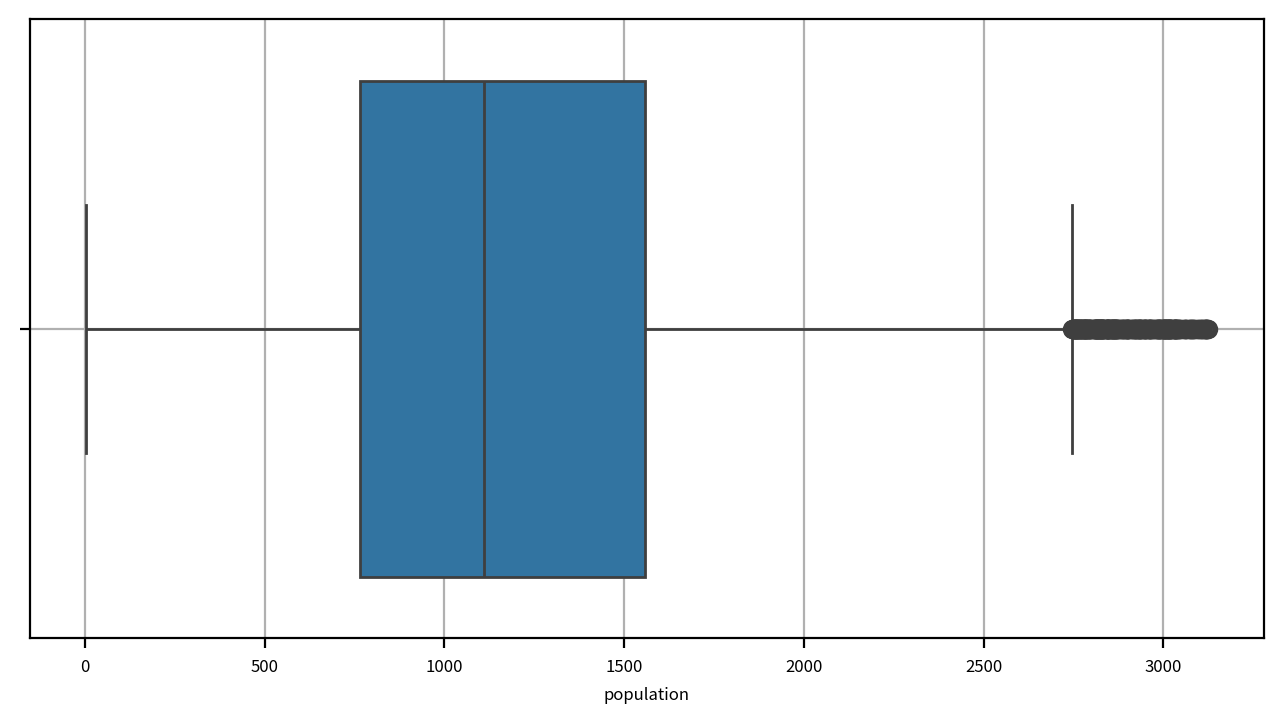

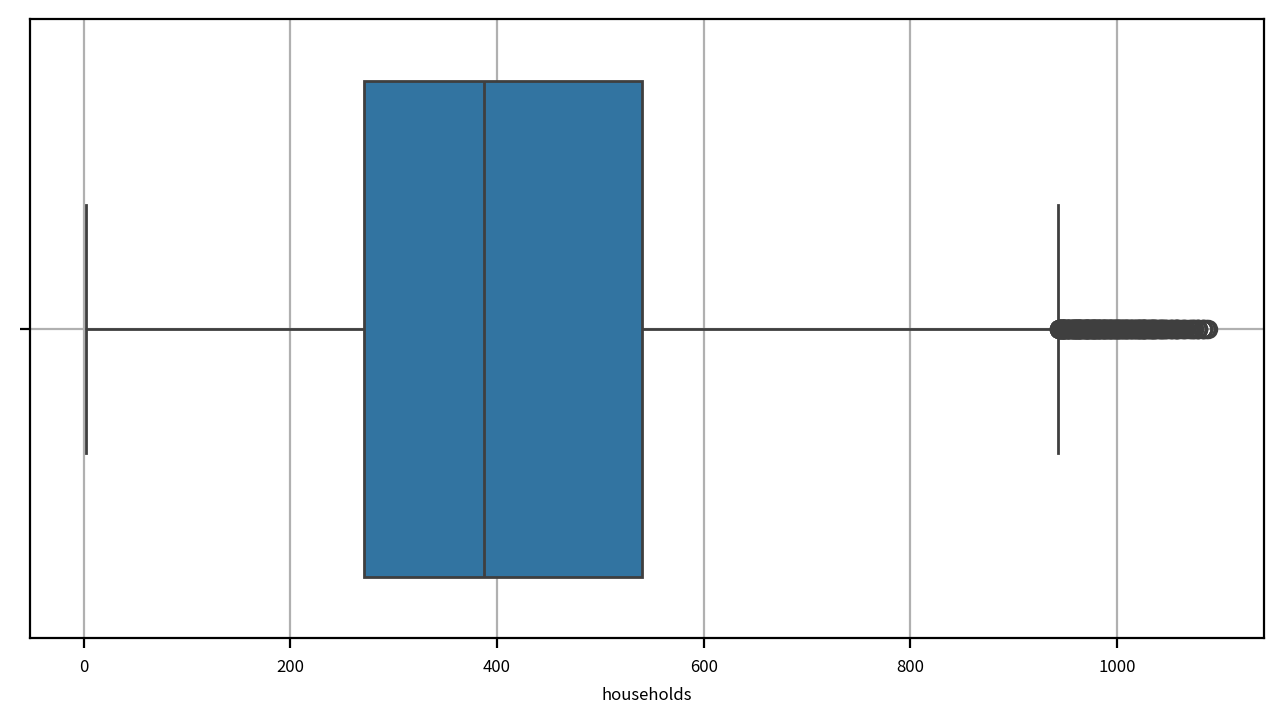

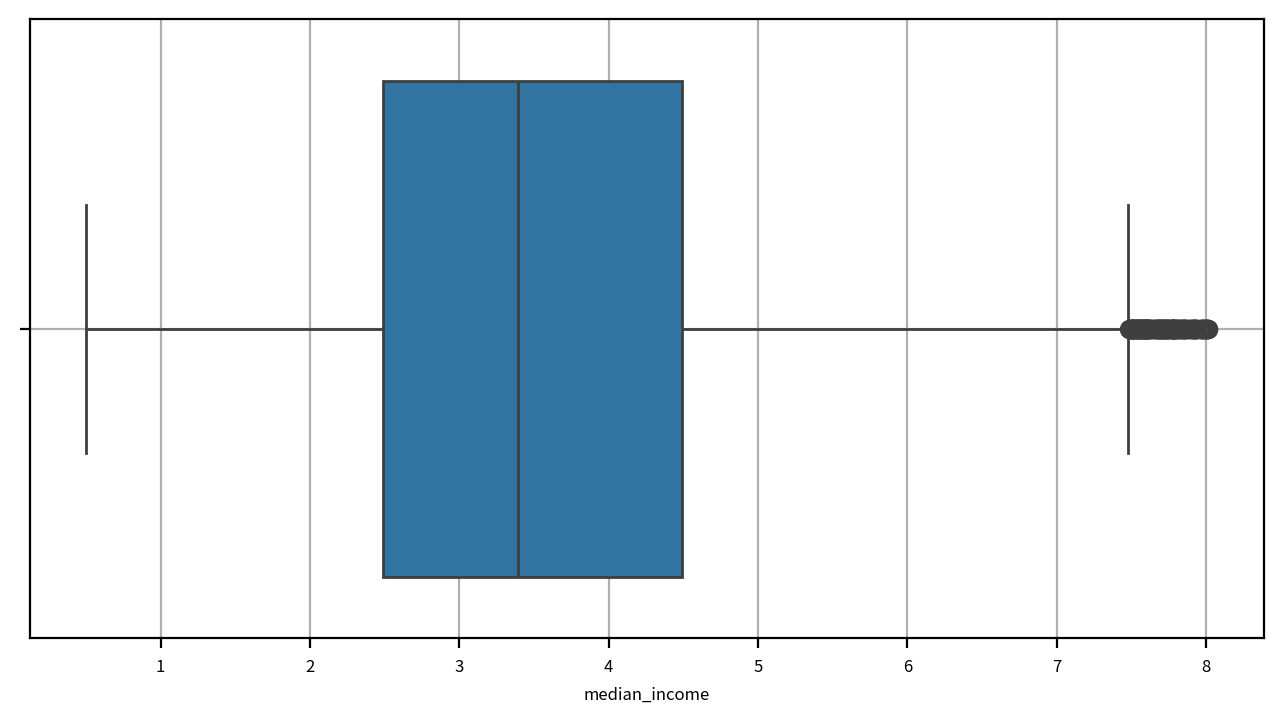

In [44]:
mylist=['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income']
for i in mylist:
    plot.hs_boxplot(df=df2[i], orient='h')

## 🎯미션2. 가격과 핵심 변수의 그래프 확인

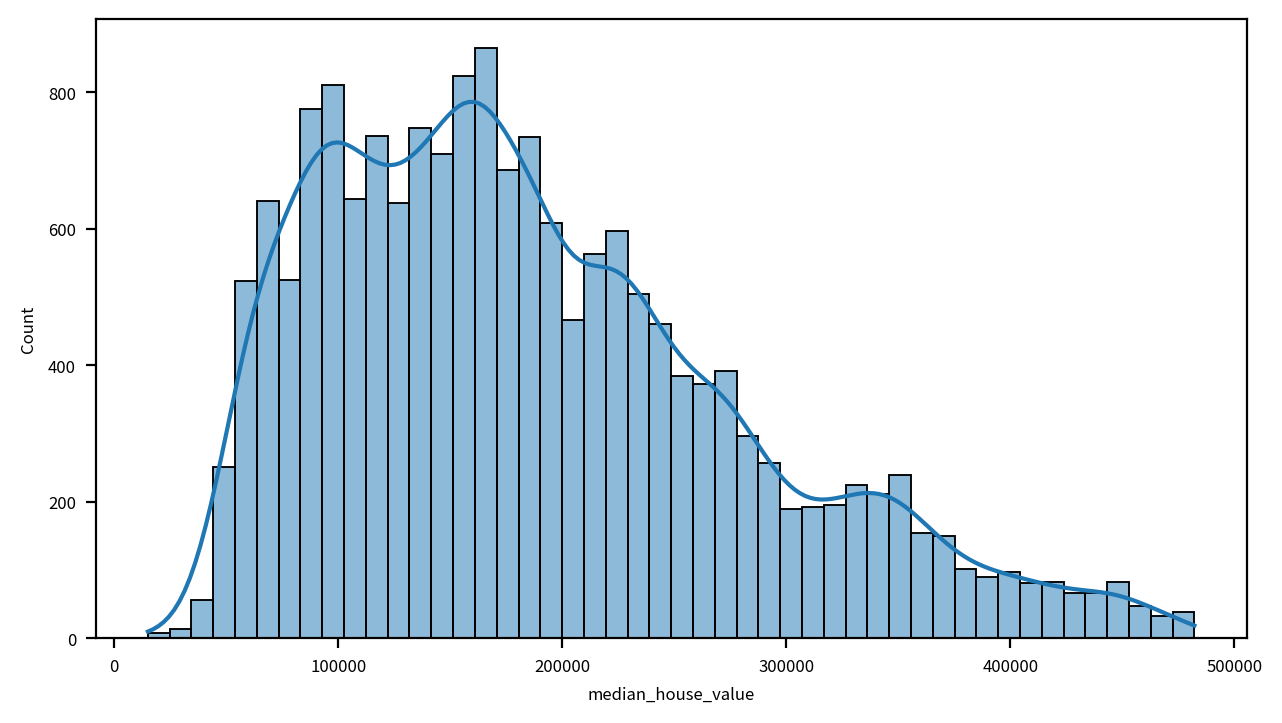

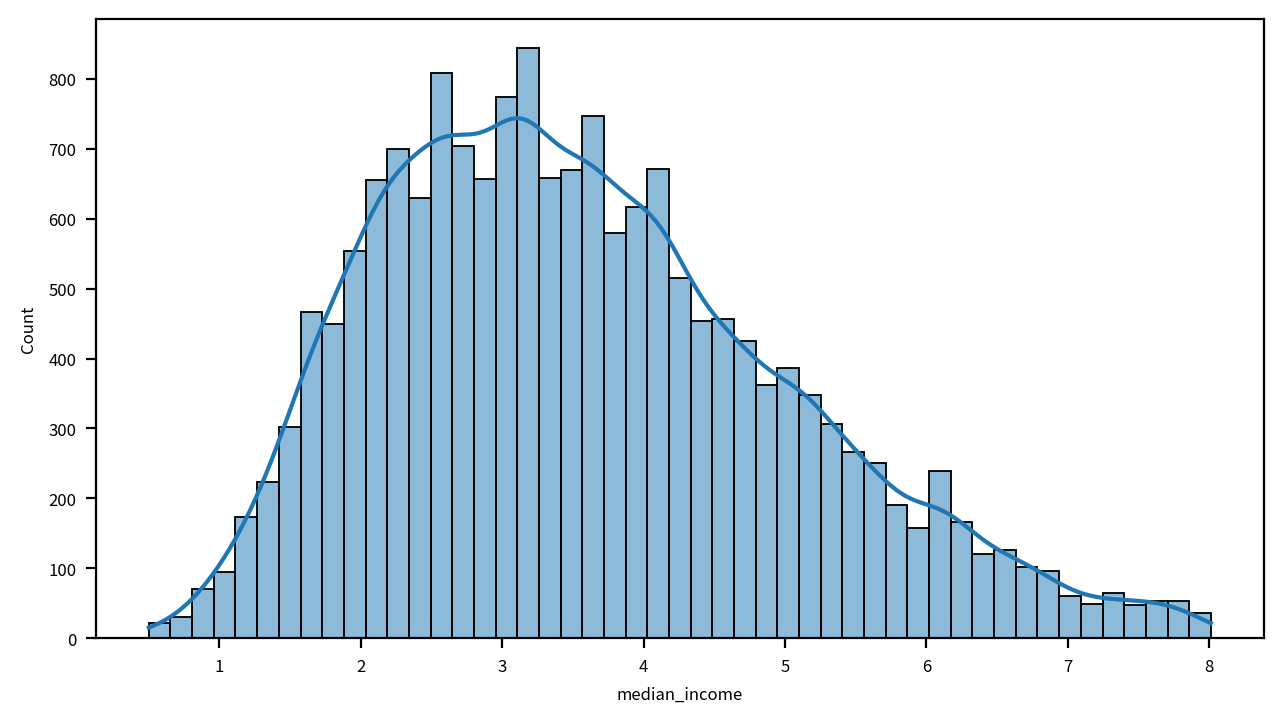

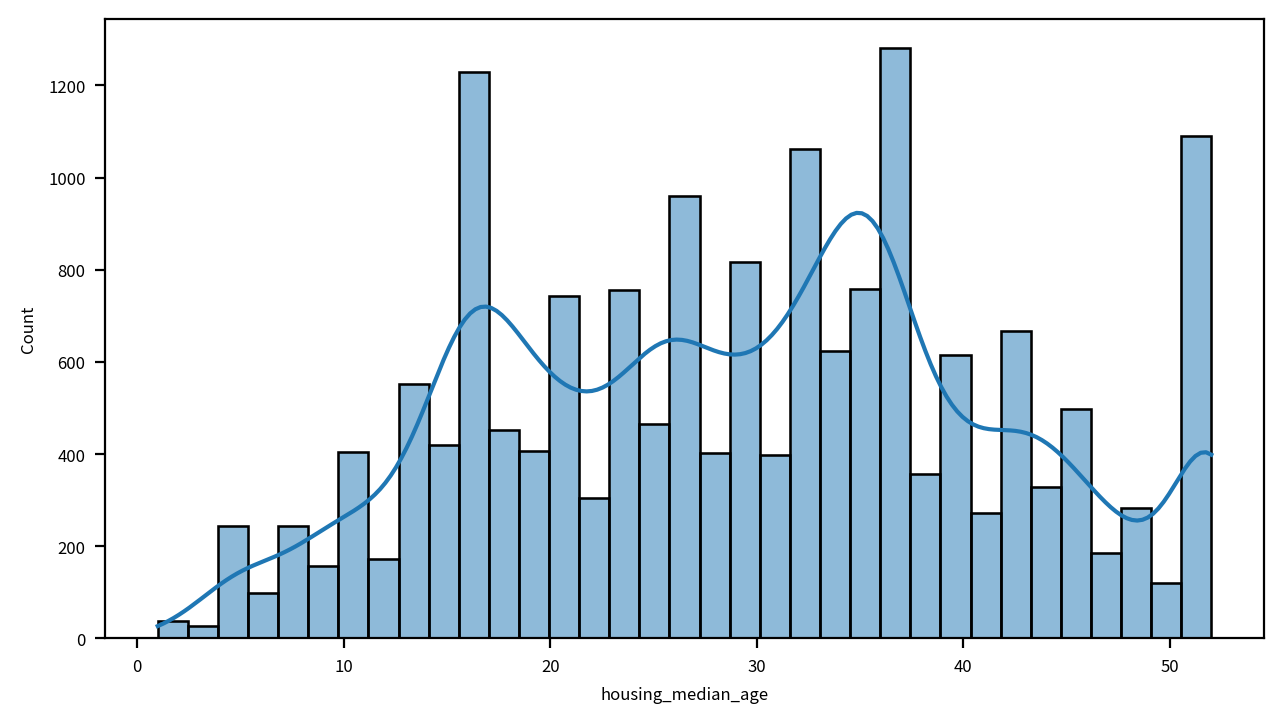

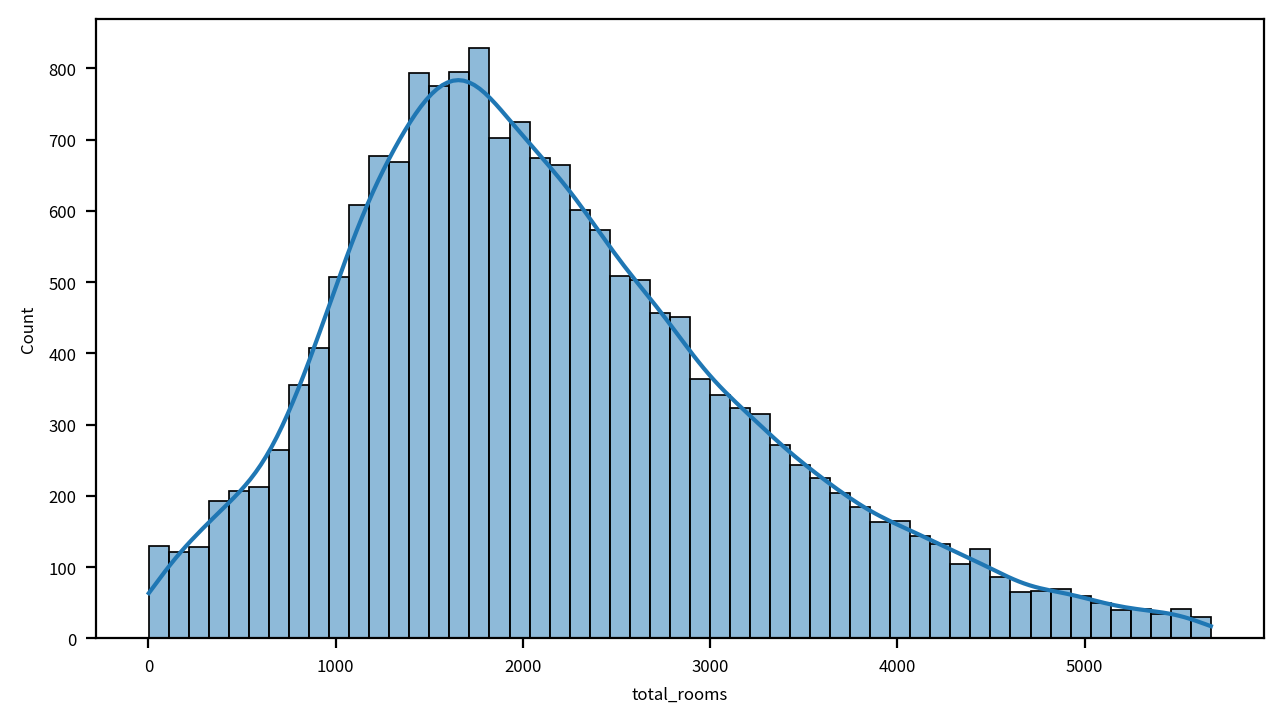

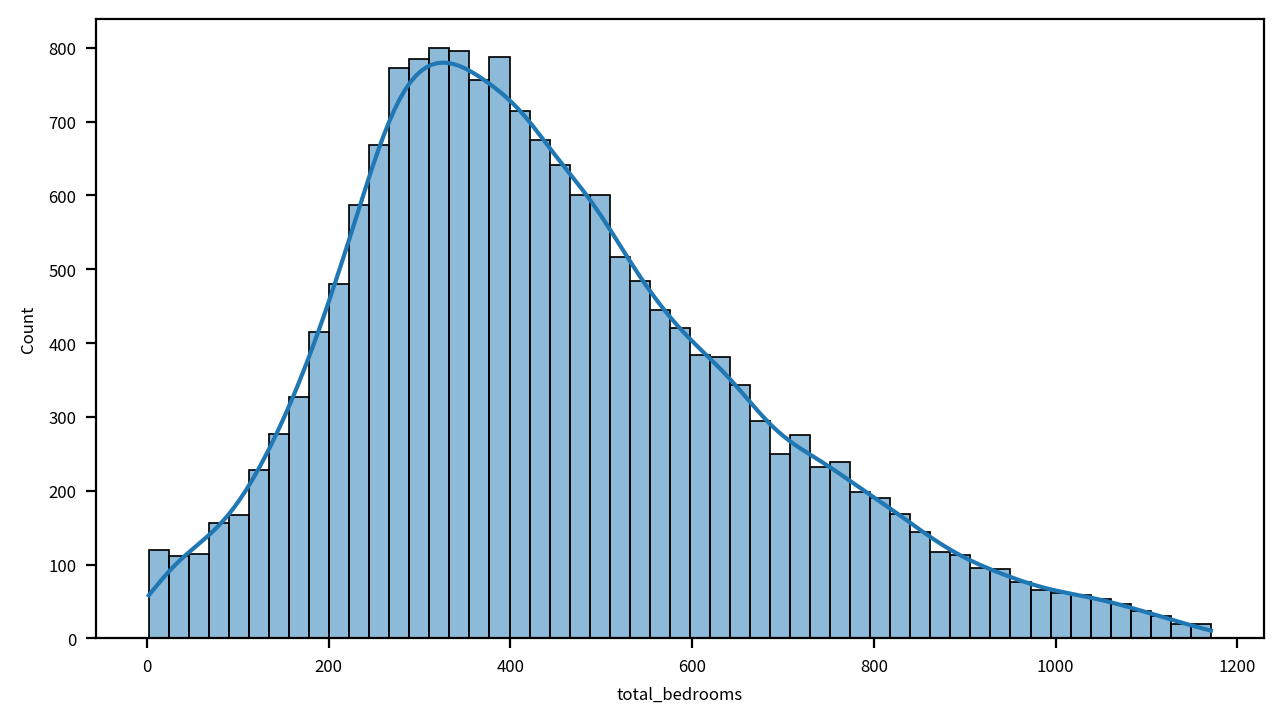

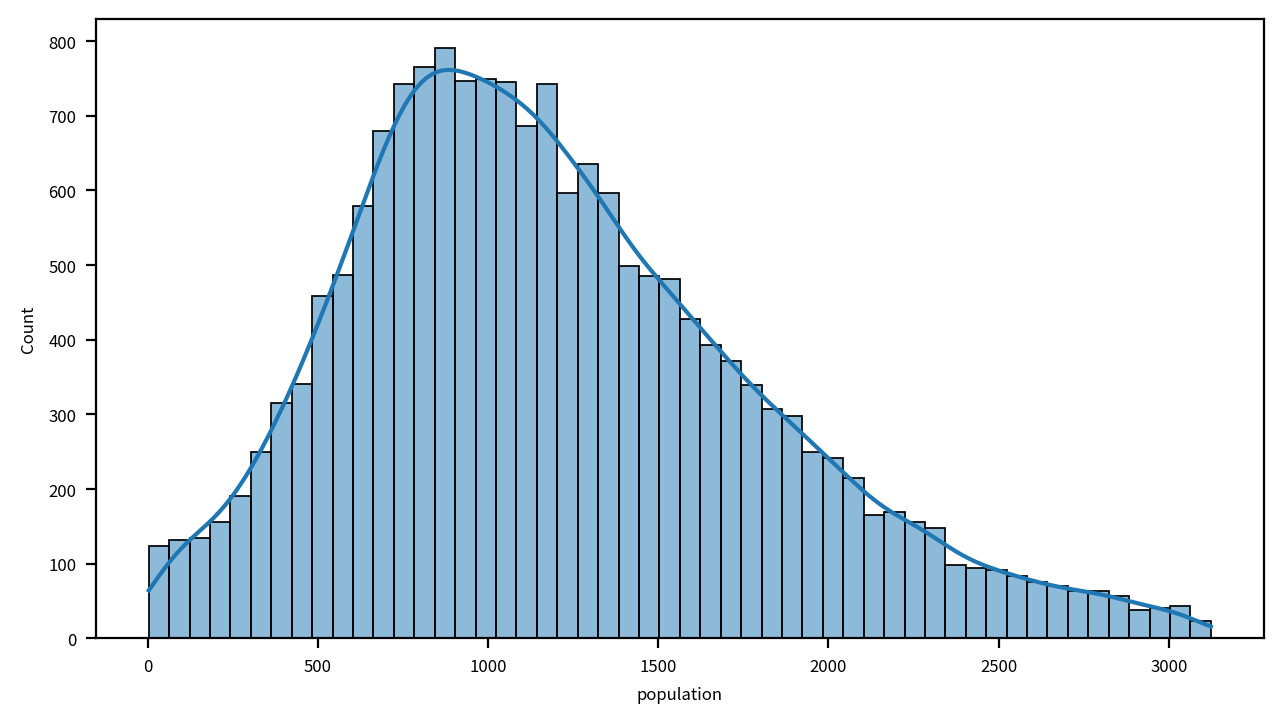

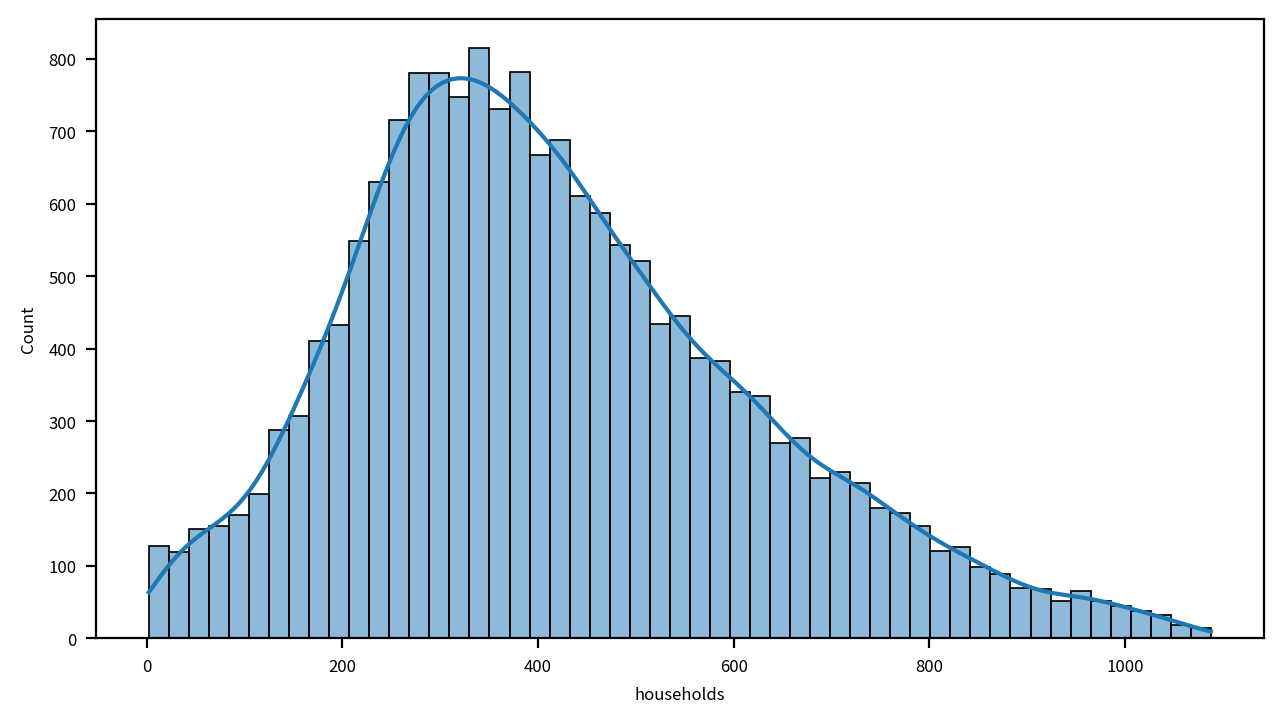

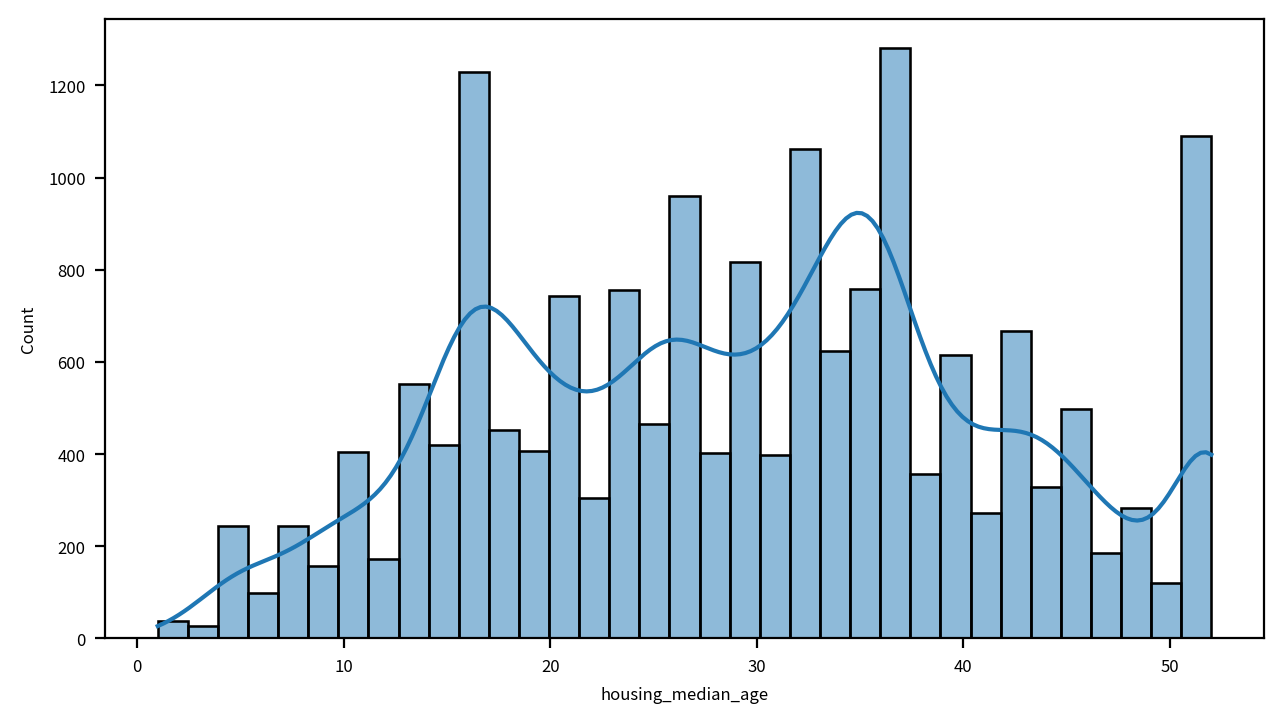

In [45]:
mylist1=['median_house_value', 'median_income', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'housing_median_age']
for i in mylist1:
    plot.hs_histplot(df=df2, xname=i, kde=True)

주택 중위가격과 구역 내 모든 주택의 방 수 합계는 오른쪽으로 긴 꼬리가 형성됨.   
주택 중위 연령은 정규성이 보이지 않기에, 로그 변환 혹은 제곱근 변환을 활용할 가능성이 높음.  
주택 중위 연령을 제외한 변수들은 오른쪽으로 긴 꼬리를 가지는 분포를 보임.   
꼬리 분포를 가지는 형태들에 대해 로그 또는 제곱근으로 변환하기.  

## 🎯미션3. 로그 or 제곱근 변환 고려

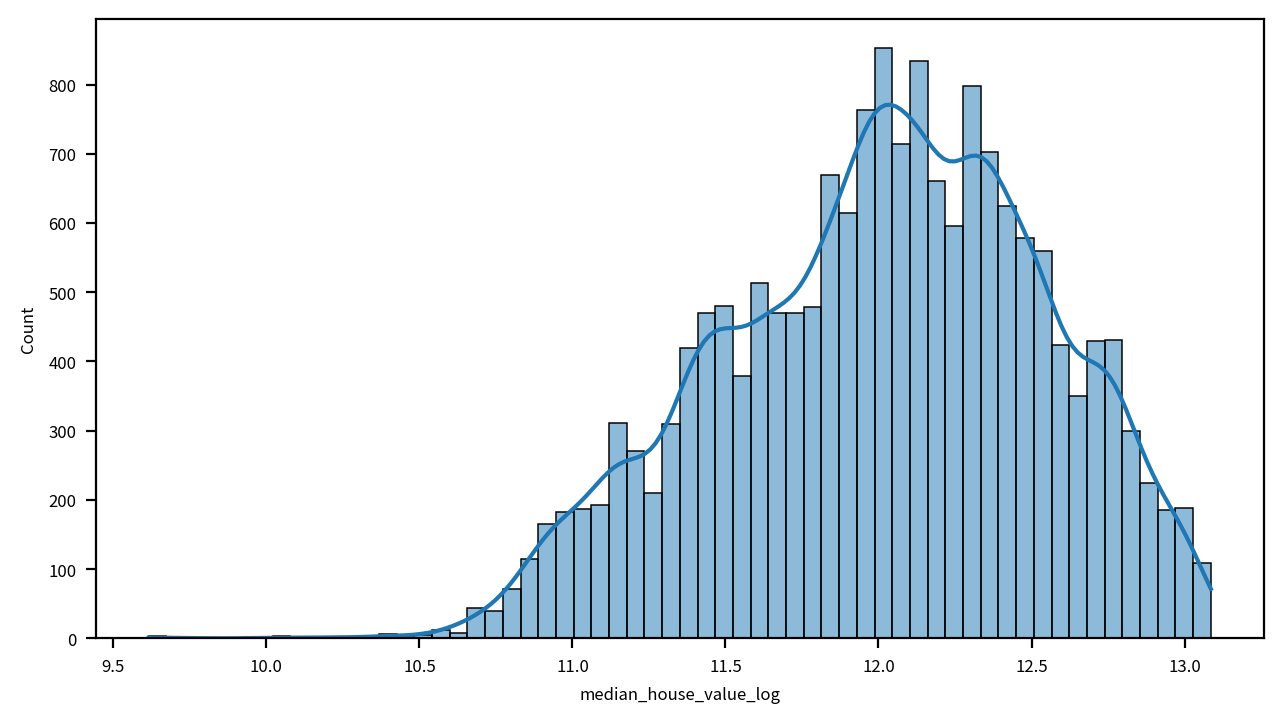

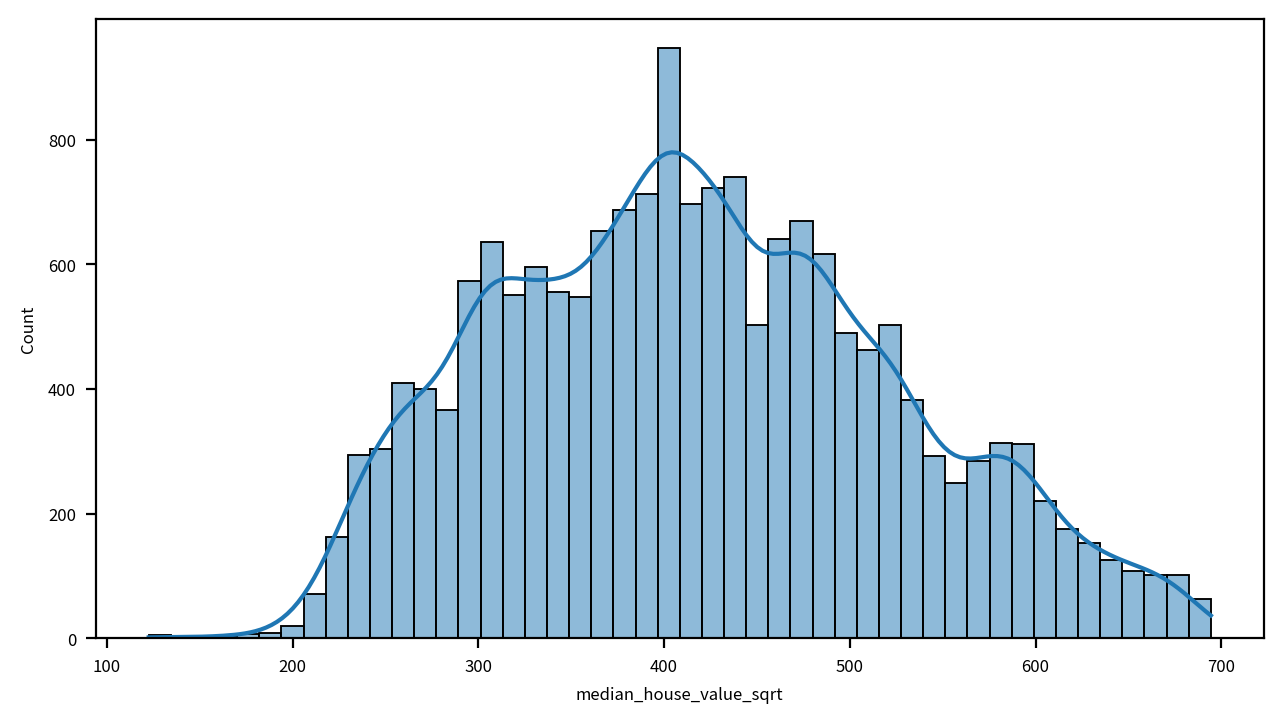

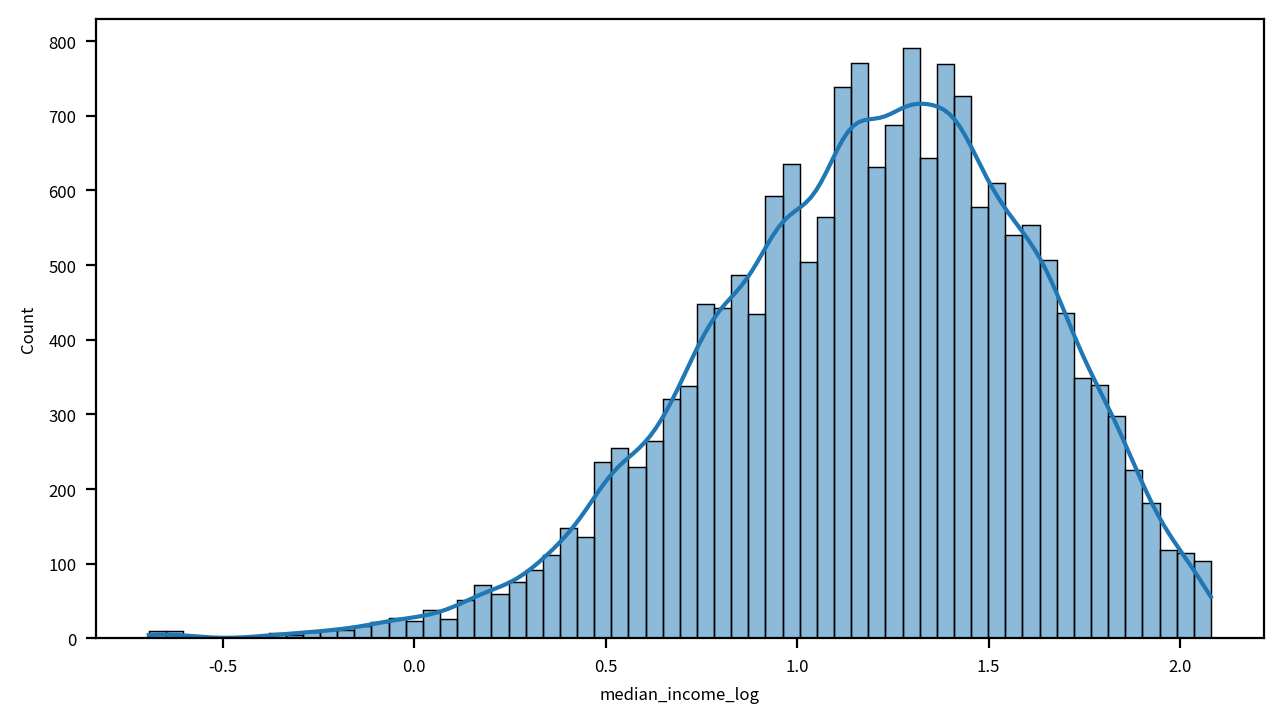

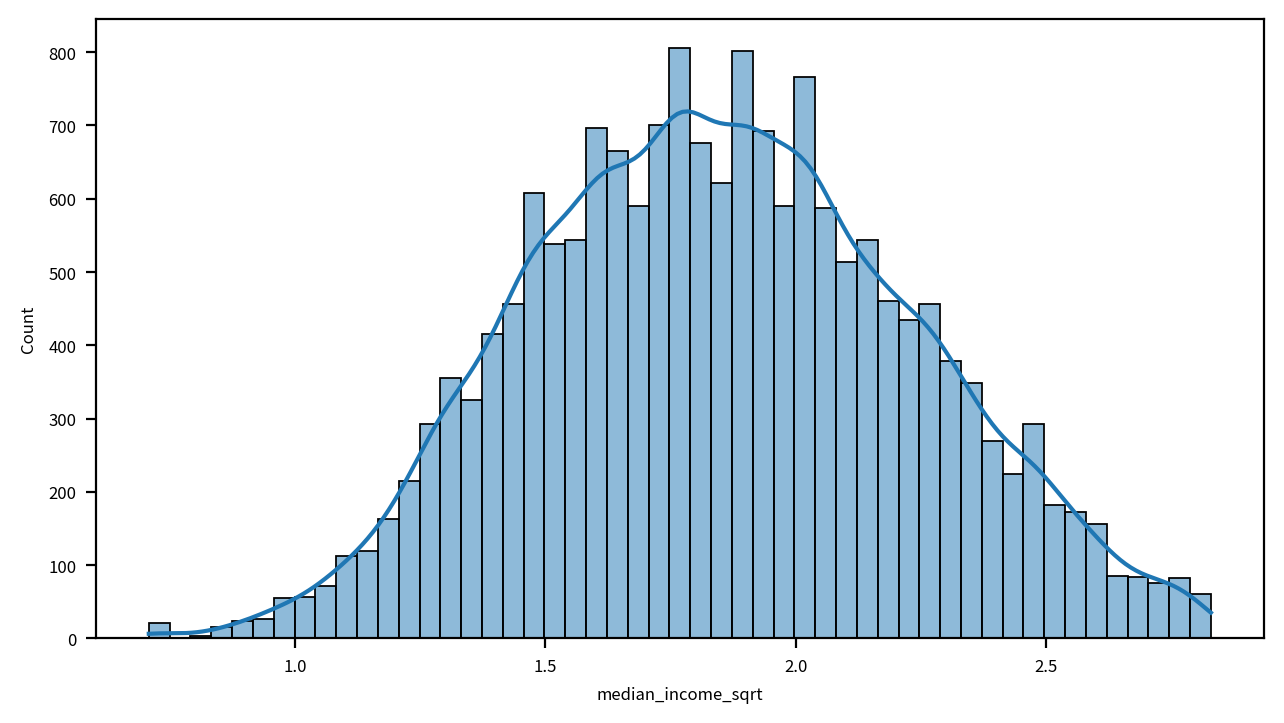

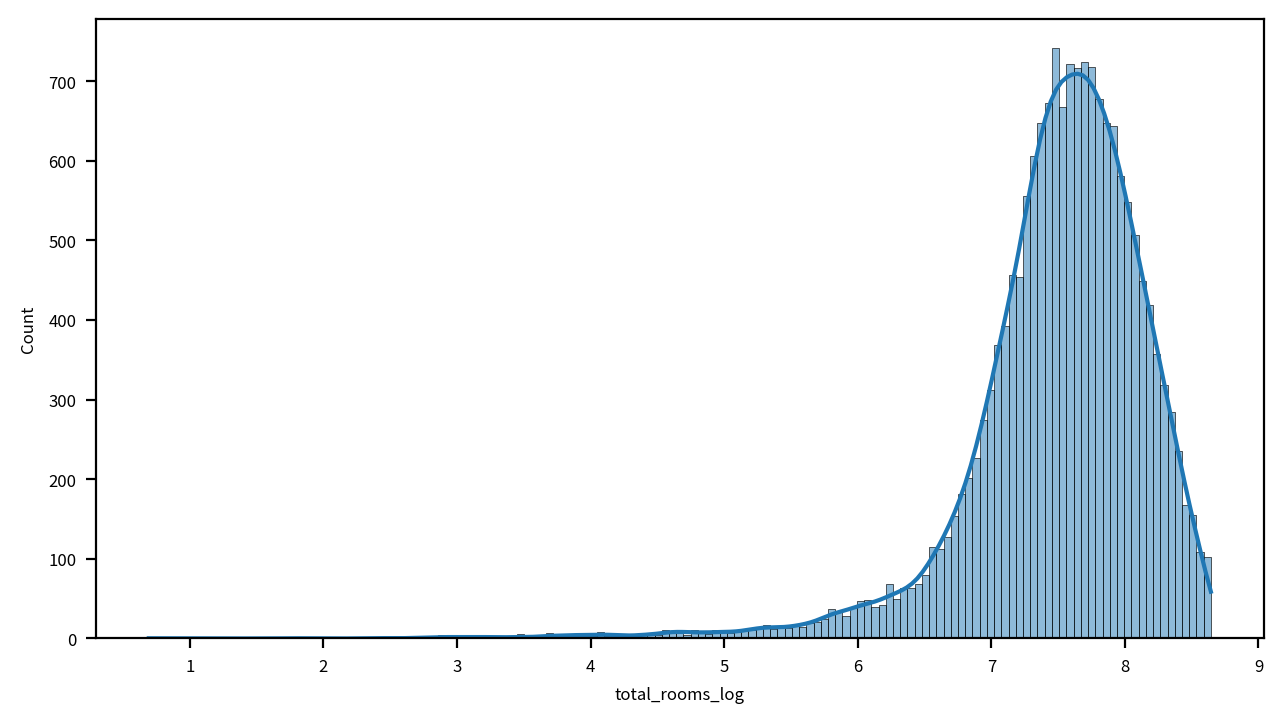

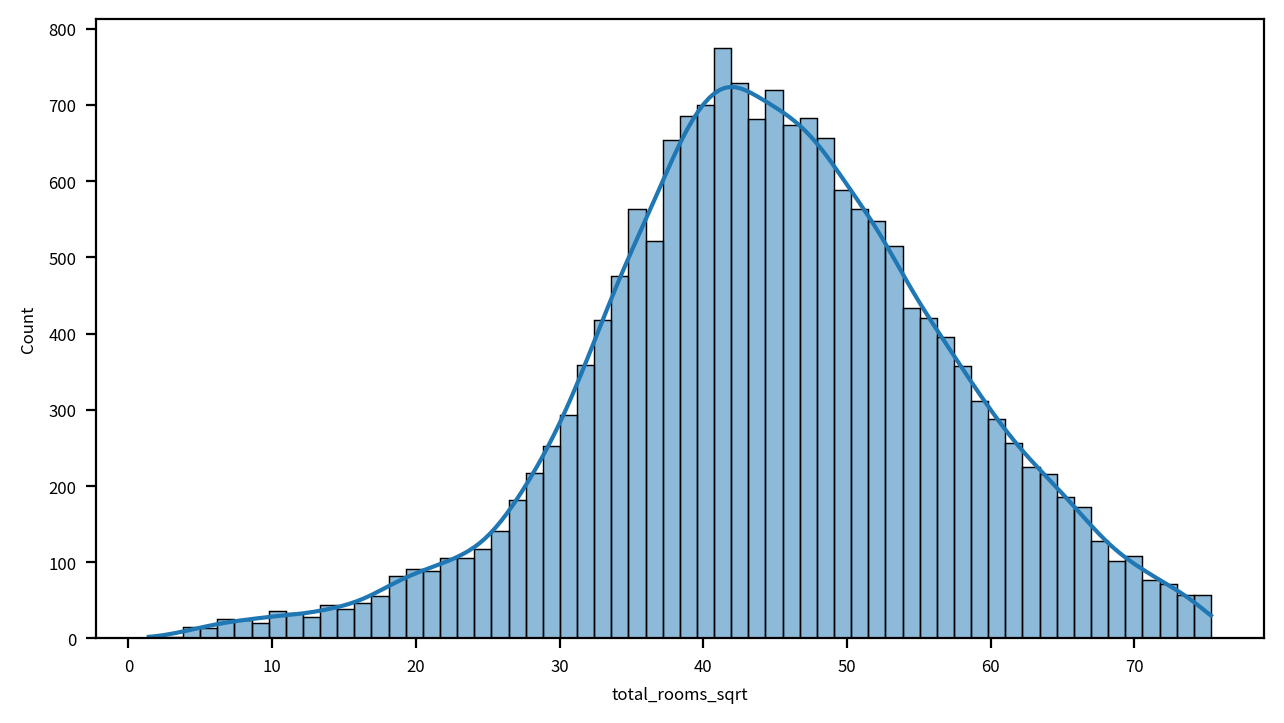

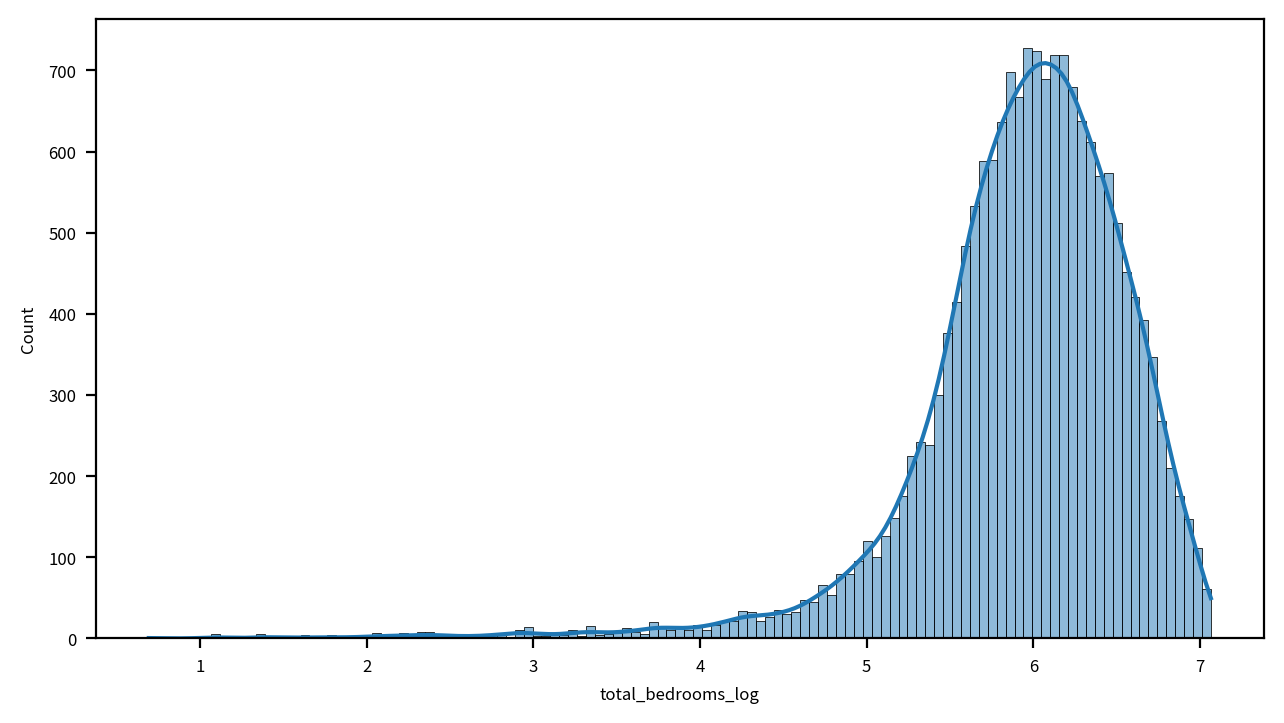

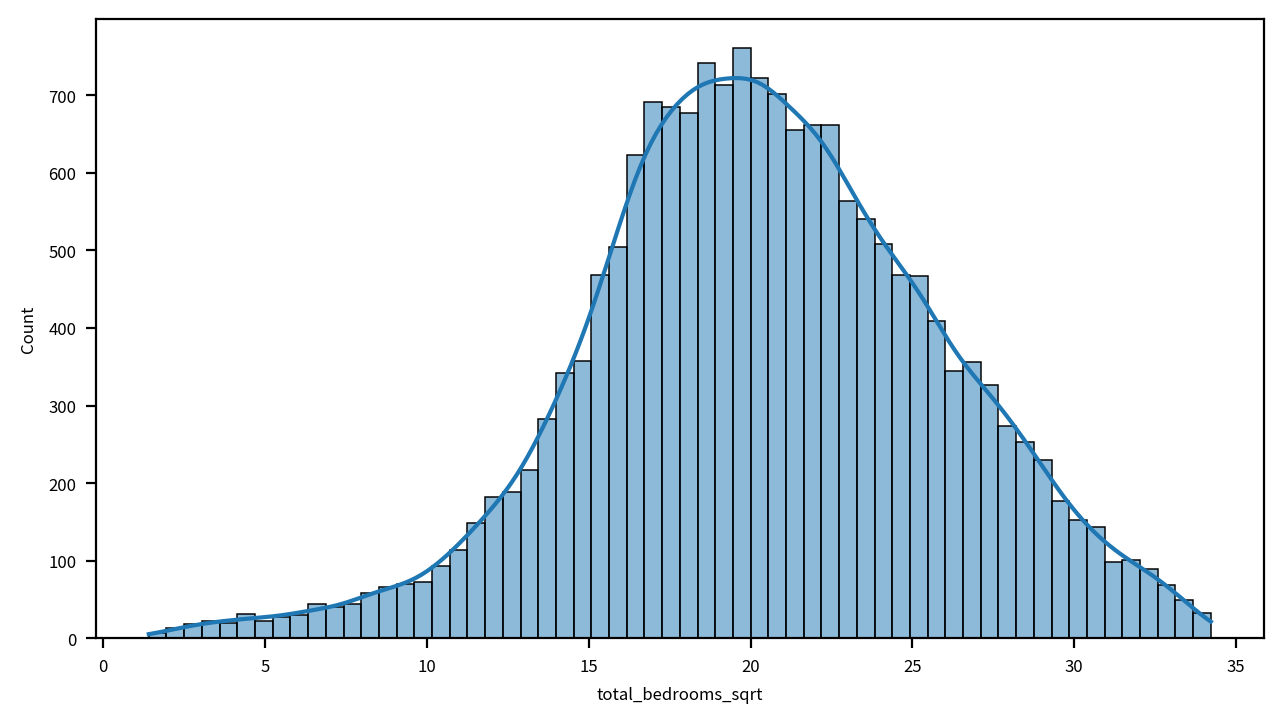

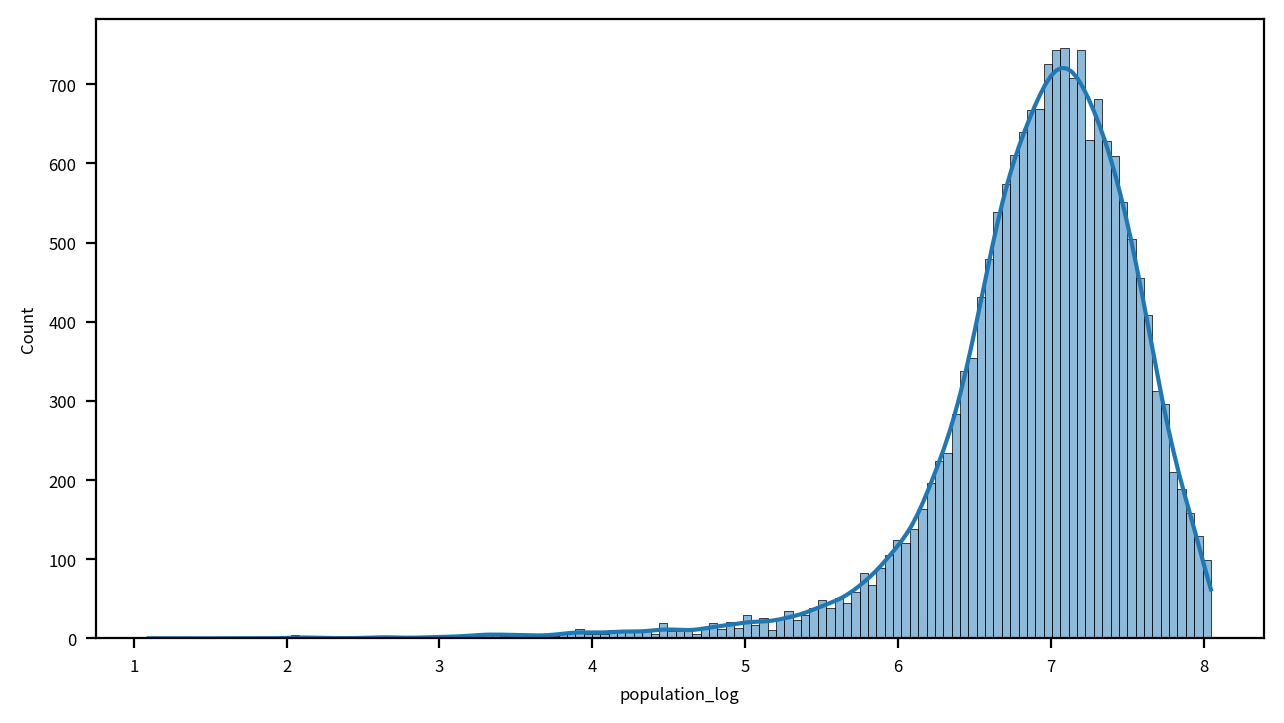

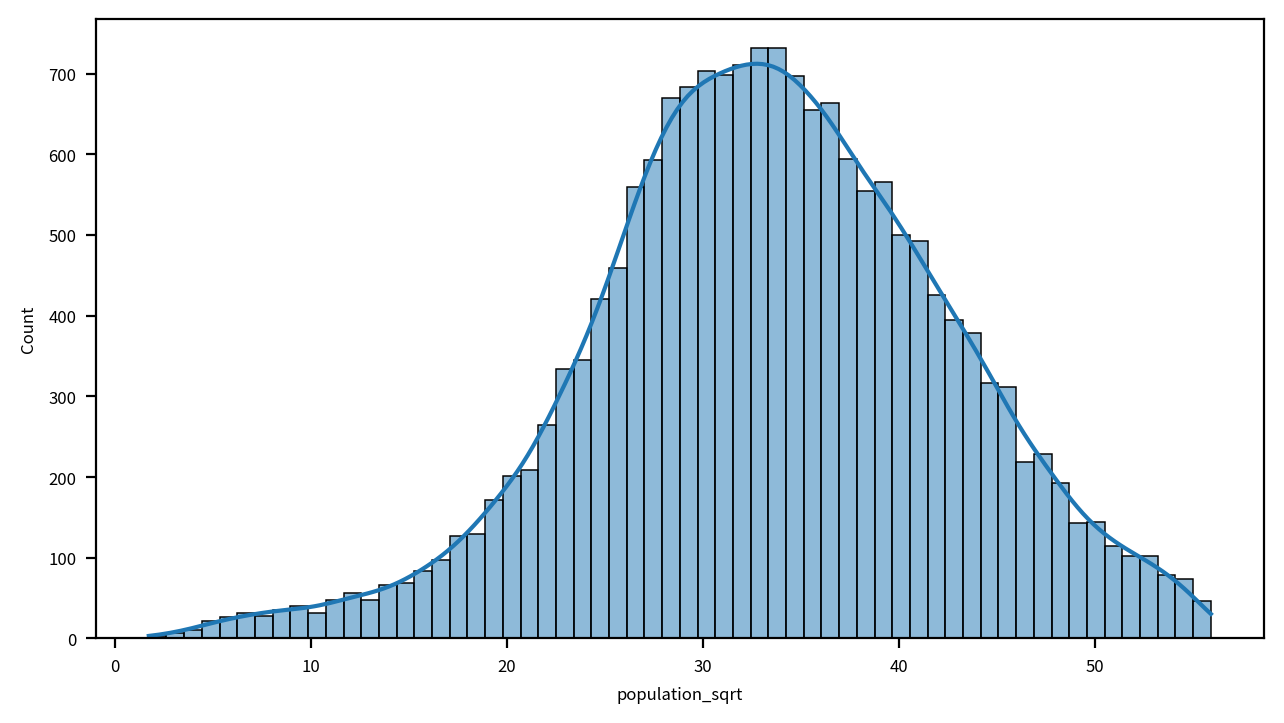

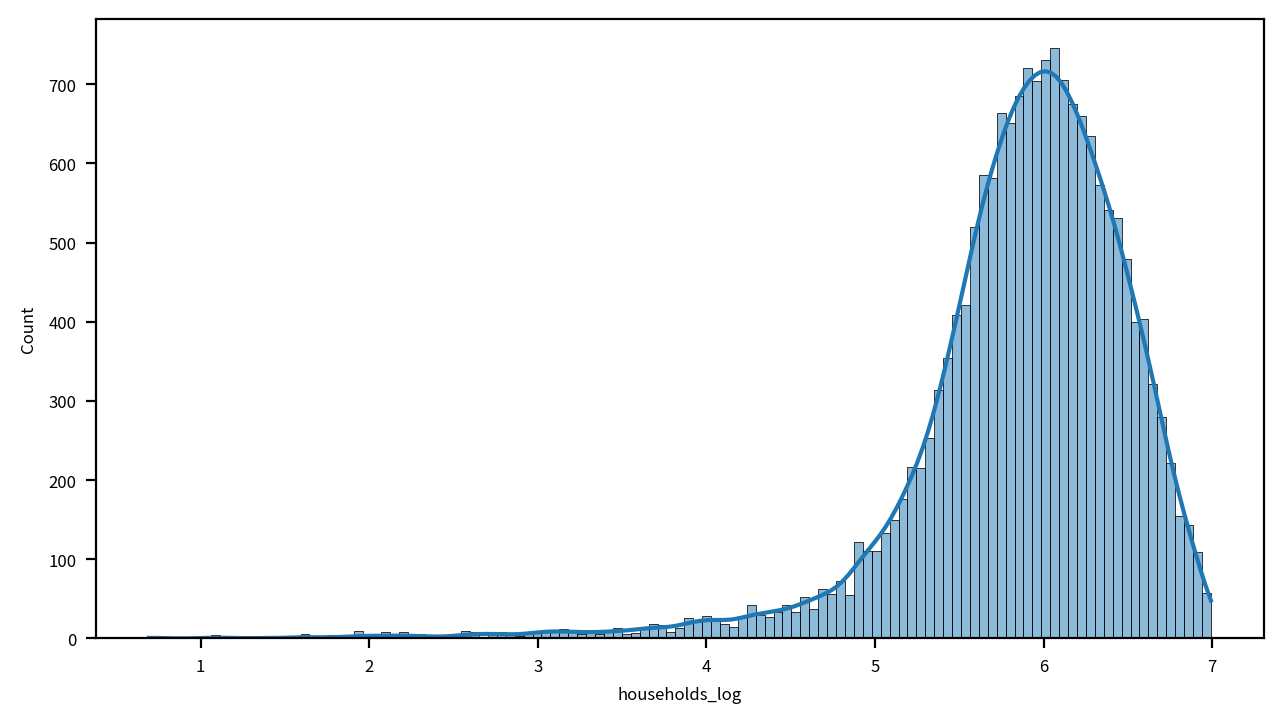

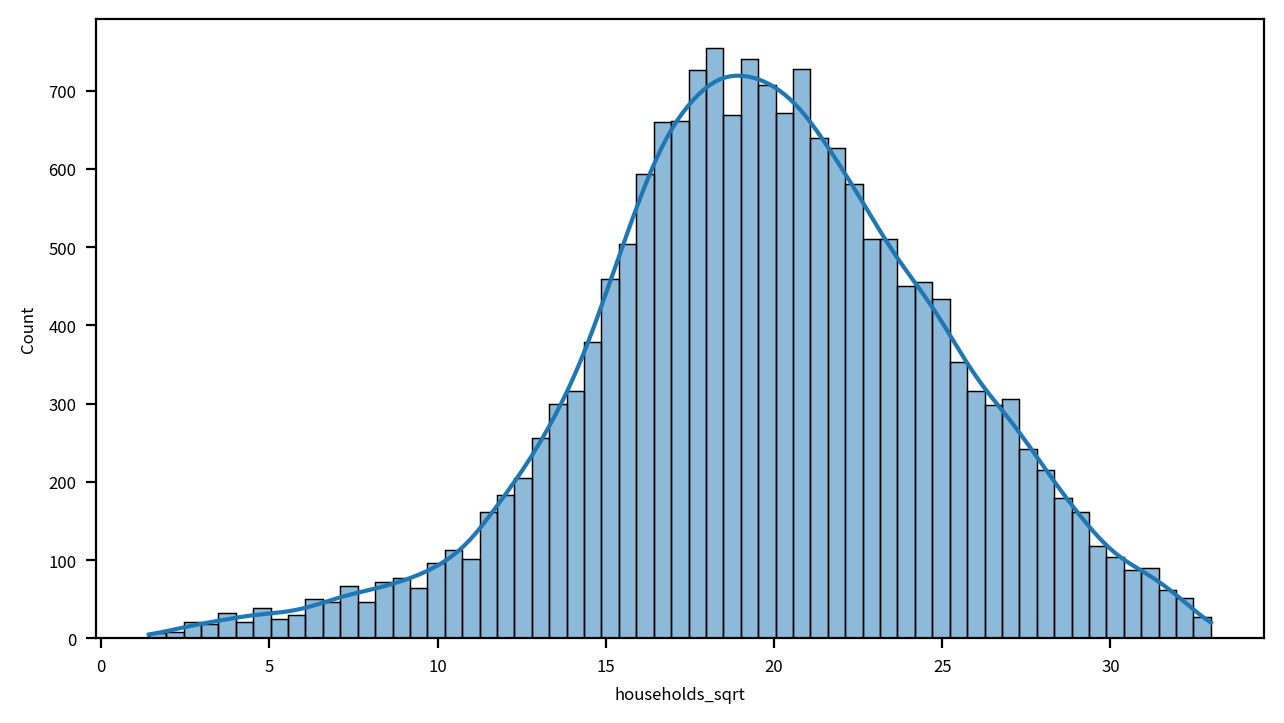

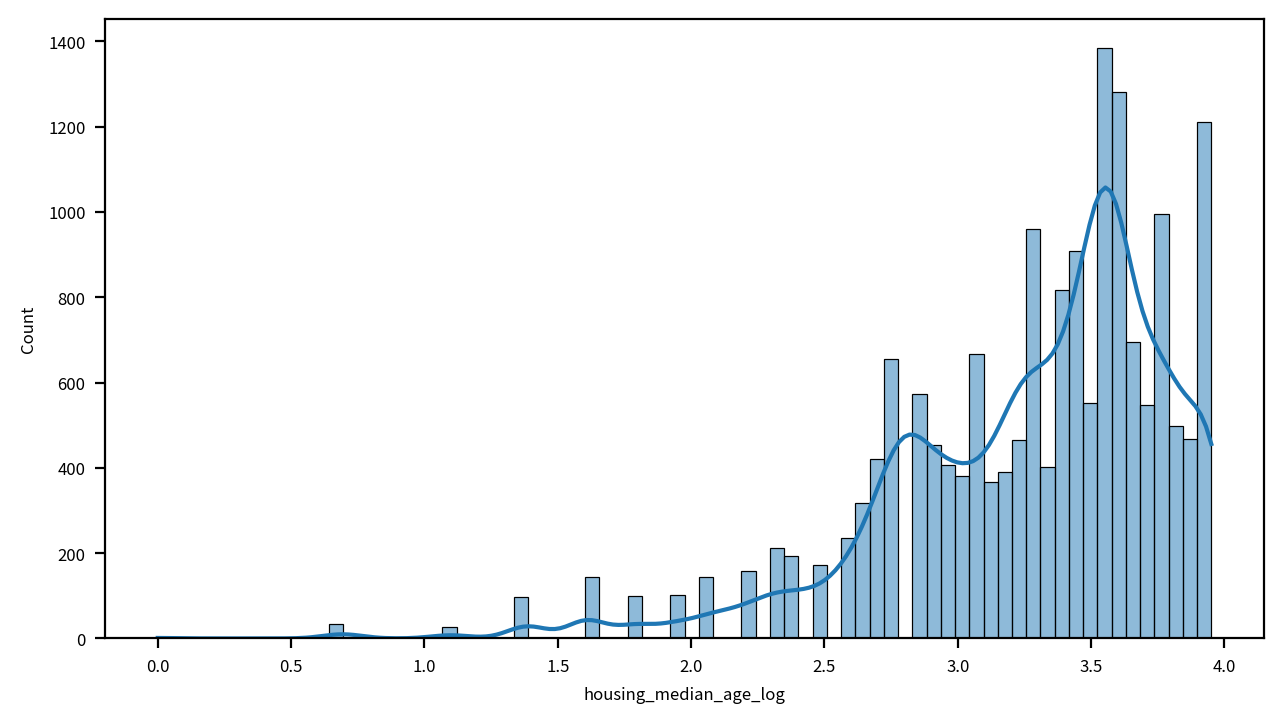

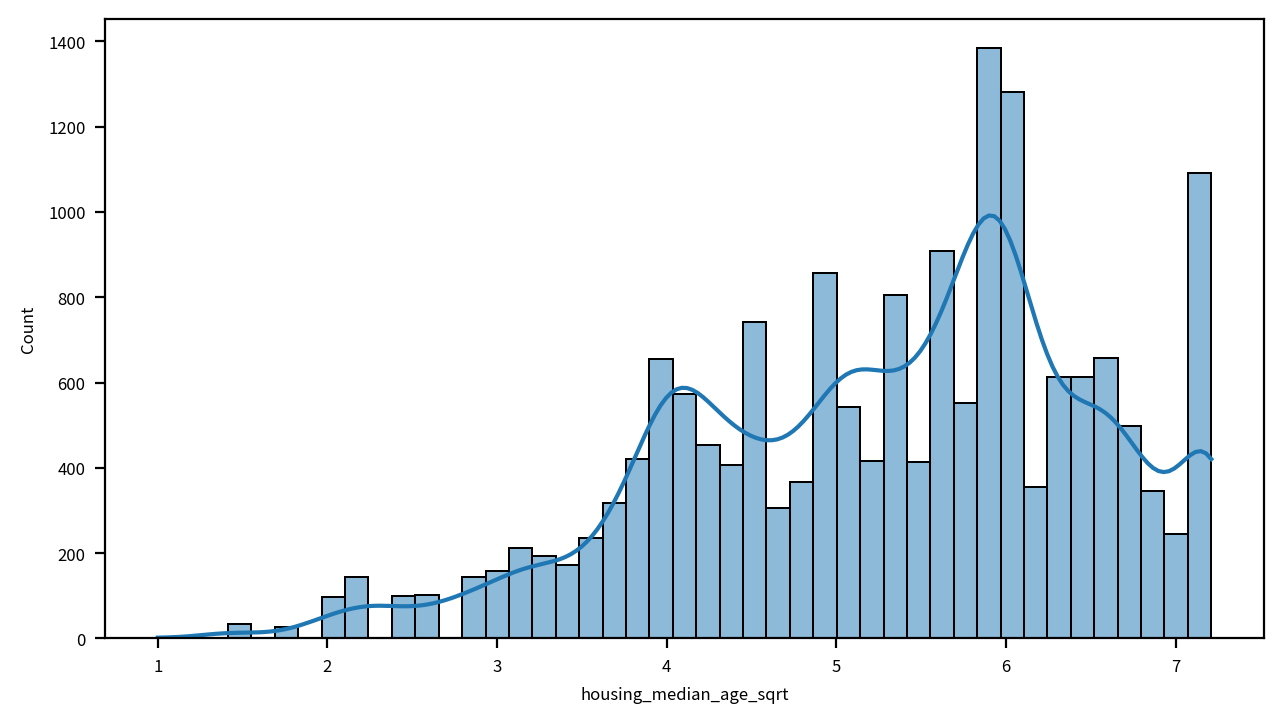

In [46]:
change_list=['median_house_value', 'median_income', 'total_rooms', 'total_bedrooms', 'population', 'households', 'housing_median_age']
for i in change_list:
    df2[f'{i}_log']=np.log(df1[i])
    df2[f'{i}_sqrt']=np.sqrt(df1[i])
    plot.hs_histplot(df=df2, xname=f'{i}_log', kde=True)
    plot.hs_histplot(df=df2, xname=f'{i}_sqrt', kde=True)

'median_house_value', 'median_income', 'total_rooms', 'total_bedrooms', 'population', 'households' 변수들 모두 제곱근을 취했을 때에 정규성을 잘 보여주어서, 제곱근 변수로 데이터 분석을 진행할 예정.  

## 🎯미션4. 지리적 위치(위도, 경도)의 중요성 확인

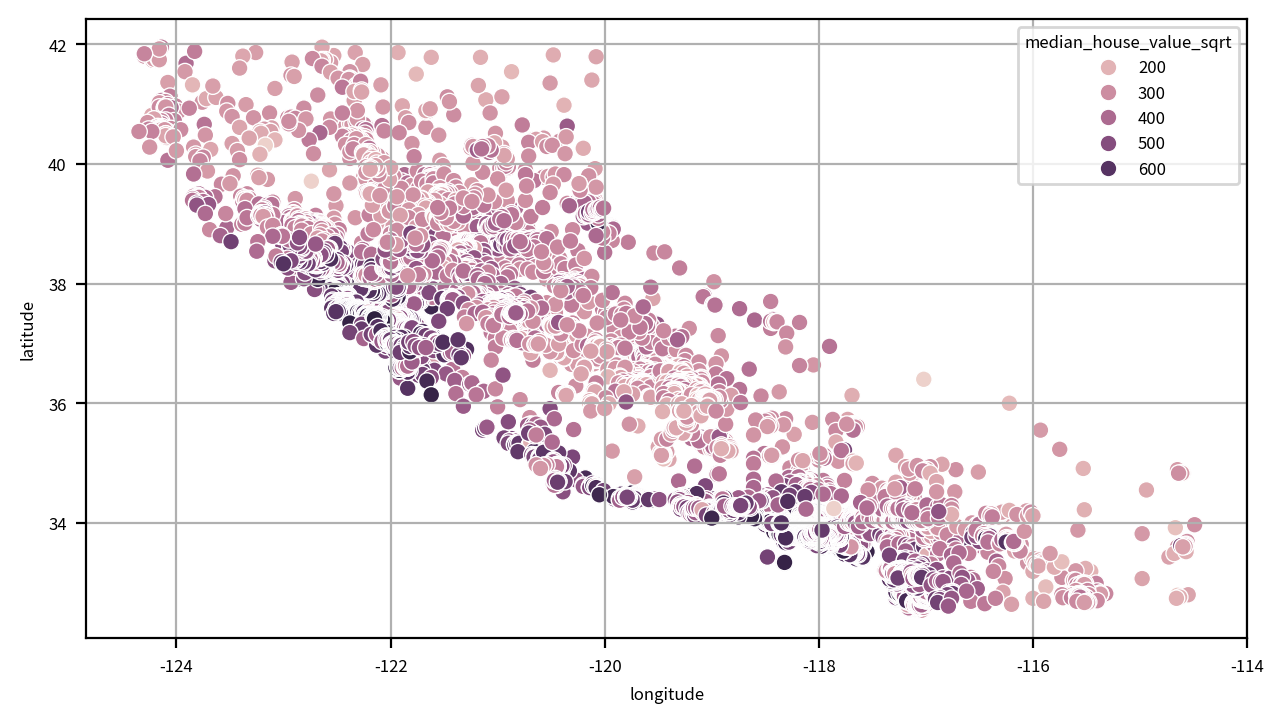

In [47]:
plot.hs_scatterplot(df=df2, xname='longitude', yname='latitude', hue='median_house_value_sqrt')

위 그래프는 색이 연할 수록 주택 가격이 낮은 것이고, 색이 진할 수록 주택 중위 가격이 높은 것이다.  
주택 중위 가격이 낮을수록 위도와 경도가 높아지는 것을 알 수 있고, 반대로 주택 중위 가격이 높을 수록 위도와 경도가 낮아지는 것을 알 수 있다.  
이는 위도와 경도가 낮을 수록 상대적으로 기후가 온화하다는 점을 고려하면 날씨가 온화한 지역일 수록 주택 중위 가격이 상승한다는 것을 시사하고 있다.  

## 🎯미션5. 소득이 집값에 미치는 영향 분석

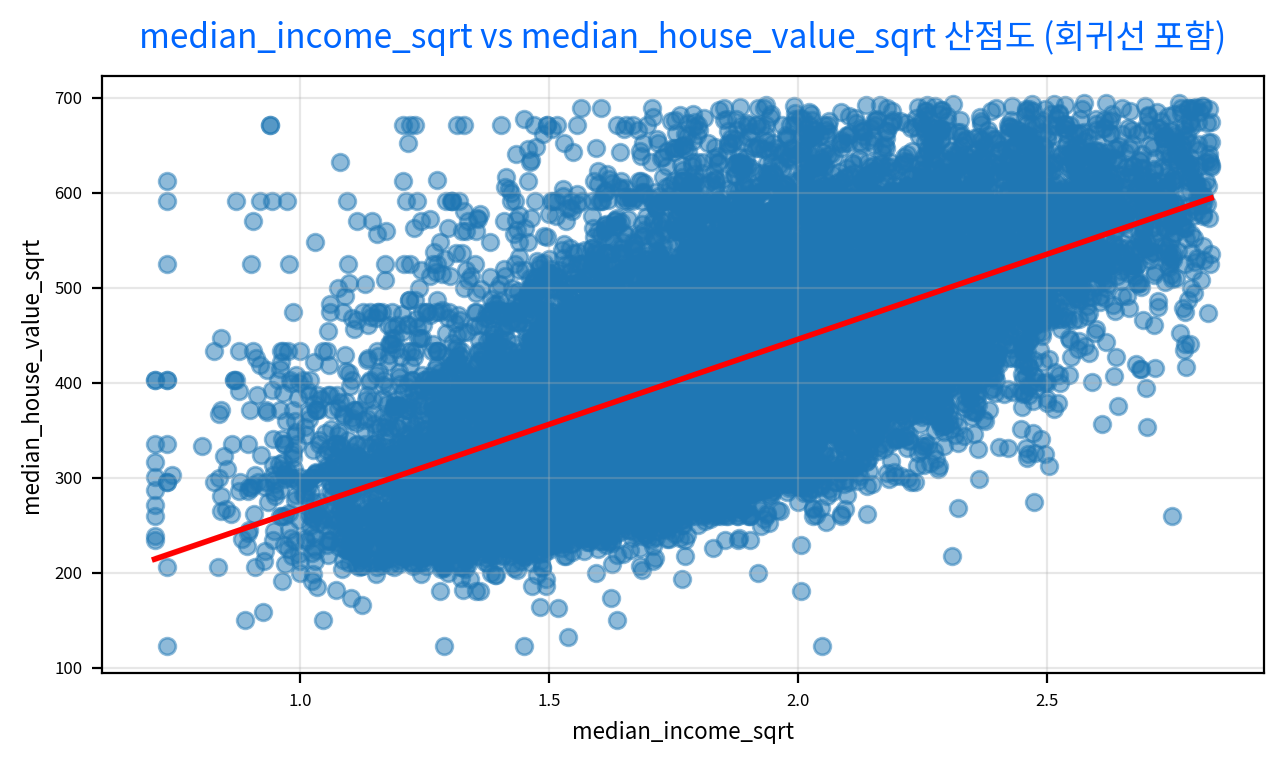

Ramsey RESET Test : 선형성 위반 (p-value : 0.0000)


,original_skew,log_skew,outliers(|z|>3),log_recommended
median_income_sqrt,0.087332,-0.217533,0,False
median_house_value_sqrt,0.252556,-1.016488,0,False


이상치가 발견되지 않음
📊 상관계수 요약
Pearson r: 0.639, p-value: 0.0000
Spearman rho: 0.645, p-value: 0.0000

✅ 최종 선택 결과
선택된 방법: spearman
상관계수: 0.645
p-value: 0.0000
선택 근거: 비선형(또는 이상치 영향) 가능성 고려


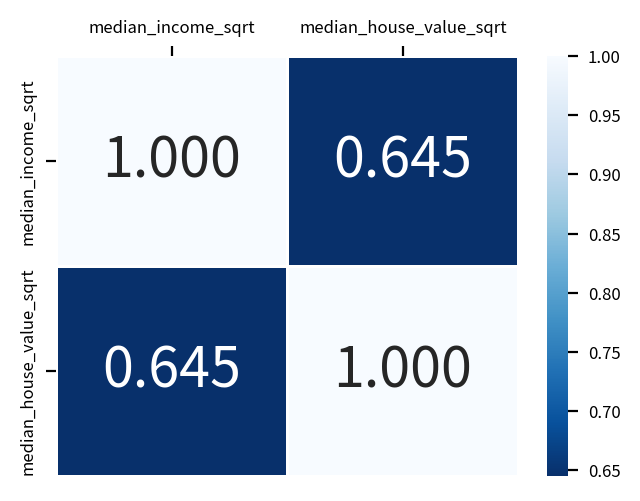


🎓 인사이트

본 분석에서는 median_income_sqrt와(과) median_house_value_sqrt 간 상관관계를 검토하였다.
데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.
분석 결과, 스피어만 상관계수는 rho=0.6454, p=0.0000로 나타나 두 변수간 유의한 양의 단조 관계가 통계적으로 유의함을 확인하였다.


In [48]:
# 데이터 입력
xdata='median_income_sqrt'
ydata='median_house_value_sqrt'

# 패키지 참조
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr

# 그래프 초기화
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

# 산점도 그래프
width_px=1280
height_px=760
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.regplot(data=df2, x=xdata, y=ydata, scatter_kws={'alpha':0.5}, line_kws={'color':'red', 'linewidth':2})
ax.grid(True, alpha=0.3)
ax.set_title(f'{xdata} vs {ydata} 산점도 (회귀선 포함)', color='#0066ff', fontsize=12, fontweight=1000, pad=10)
ax.set_xlabel(f'{xdata}', fontsize=8)
ax.set_ylabel(f'{ydata}', fontsize=8)
plt.tight_layout()
plt.show()
plt.close()

# 선형성 적합여부 판단
x=df2[xdata]
y=df2[ydata]
X=sm.add_constant(x)
model=sm.OLS(y,X).fit()
reset=linear_reset(model, power=2, use_f=True)
linearity_ok=reset.pvalue>0.05
print(f'Ramsey RESET Test : {"선형성 적합" if linearity_ok else "선형성 위반"} (p-value : {reset.pvalue:.4f})')

# 이상치와 왜도 검정
data=df2[[xdata, ydata]]
results={}
for col in data.columns:
    temp=data[col].dropna()
    # 왜도 계산
    skew_original=temp.skew()
    # Z-score 기반 이상치 탐지 (|z|>3)
    z_scores=zscore(temp)
    outlier_count=int(np.sum(np.abs(z_scores)>3))
    # 로그 변환 후 왜도 계산 (음수 대비 +1)
    data_log=np.log1p(temp-temp.min()+1)
    skew_log=data_log.skew()
    # 로그 변환 필요 여부 판단
    need_log=(abs(skew_original)>1) and (abs(skew_log)<abs(skew_original))
    results[col]={
        'original_skew':skew_original,
        'log_skew':skew_log,
        'outliers(|z|>3)':outlier_count,
        'log_recommended':need_log
    }
results_df=pd.DataFrame(results).T
display(results_df)
outlier_flag=len(results_df[results_df['outliers(|z|>3)']>0])>0
if outlier_flag:
    print('이상치가 발견됨')
else:
    print('이상치가 발견되지 않음')

# 상관 분석
pearson_r, pearson_p=pearsonr(df2[xdata], df2[ydata])
spearman_r, spearman_p=spearmanr(df2[xdata], df2[ydata])
if linearity_ok and not outlier_flag:
    chosen='pearson'
    corr, pval=pearson_r, pearson_p
    rationale='선형성 만족 + 왜도/이상치 영향 작음으로 판단'
else:
    chosen='spearman'
    corr, pval=spearman_r, spearman_p
    rationale='비선형(또는 이상치 영향) 가능성 고려'
print('='*50)
print('📊 상관계수 요약')
print('='*50)
print(f'Pearson r: {pearson_r:.3f}, p-value: {pearson_p:.4f}')
print(f'Spearman rho: {spearman_r:.3f}, p-value: {spearman_p:.4f}')
print('\n'+'='*50)
print('✅ 최종 선택 결과')
print('='*50)
print(f'선택된 방법: {chosen}')
print(f'상관계수: {corr:.3f}')
print(f'p-value: {pval:.4f}')
print(f'선택 근거: {rationale}')
print('='*50)

# 상관 행렬
corr_matrix=df2[[xdata, ydata]].corr(method=chosen)
width_px=650
height_px=500
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.heatmap(data=corr_matrix, annot=True, fmt='0.3f', linewidth=0.5, cmap='Blues_r', annot_kws={'size':20})
ax.set_xlabel('')
ax.set_ylabel('')
ax.xaxis.tick_top()
plt.tight_layout()
plt.show()
plt.close()

# 인사이트
print('\n'+'='*50)
print('🎓 인사이트')
print(f'\n본 분석에서는 {xdata}와(과) {ydata} 간 상관관계를 검토하였다.')
if chosen=='pearson':
    print('데이터 점검 결과, 두 변수의 관계는 선형적이며 이상치의 영향도 크지 않아 피어슨 상관계수를 사용하였다.')
    print(f'분석 결과, 피어슨 상관계수는 r={pearson_r:.4f}, p={pearson_p:.4f}로 나타나 두 변수간 유의한','양의 상관관계가' if pearson_r>0 else '음의 상관관계가', '통계적으로 유의함을 확인하였다.')
else:
    print('데이터 점검 과정에서 비선형 관계 가능성 또는 이상치 영향이 확인되어 스피어만 상관계수를 사용하였다.')
    print(f'분석 결과, 스피어만 상관계수는 rho={spearman_r:.4f}, p={spearman_p:.4f}로 나타나 두 변수간 유의한','양의 단조 관계가' if spearman_r>0 else '음의 단조 관계가', '통계적으로 유의함을 확인하였다.')
print('='*50)

## 🎯미션6. 주택 특성 별 분석

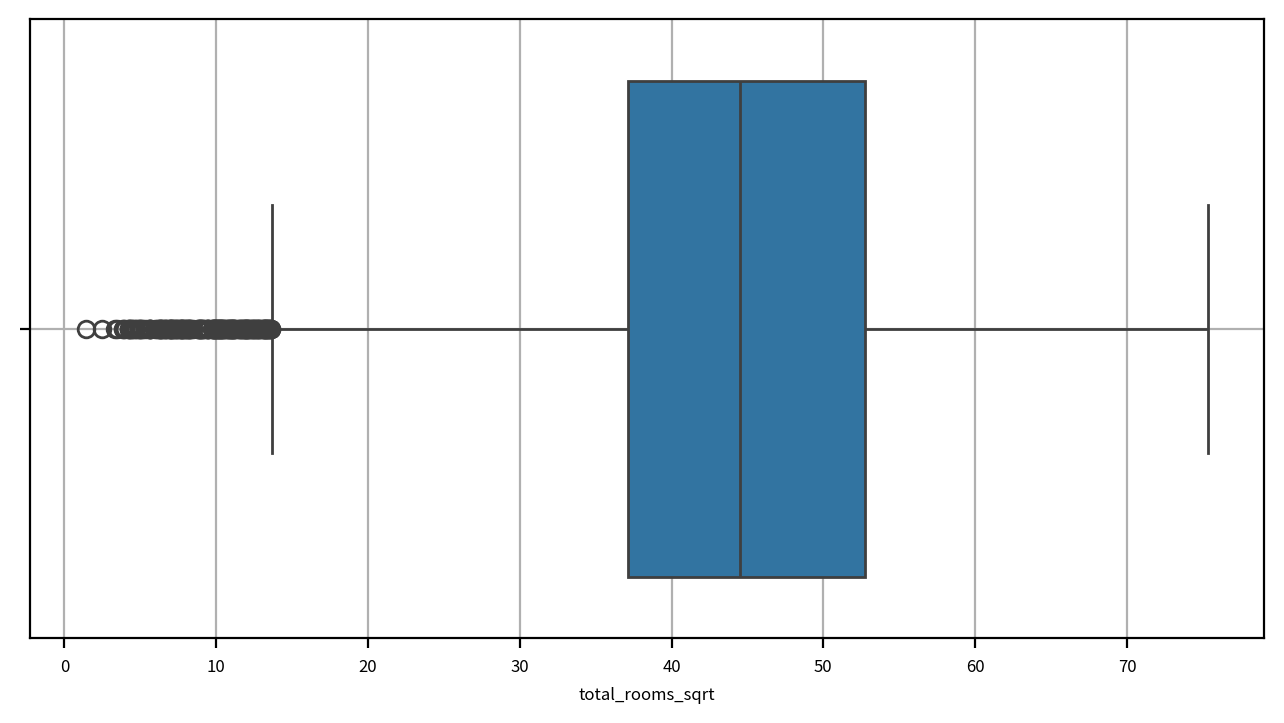

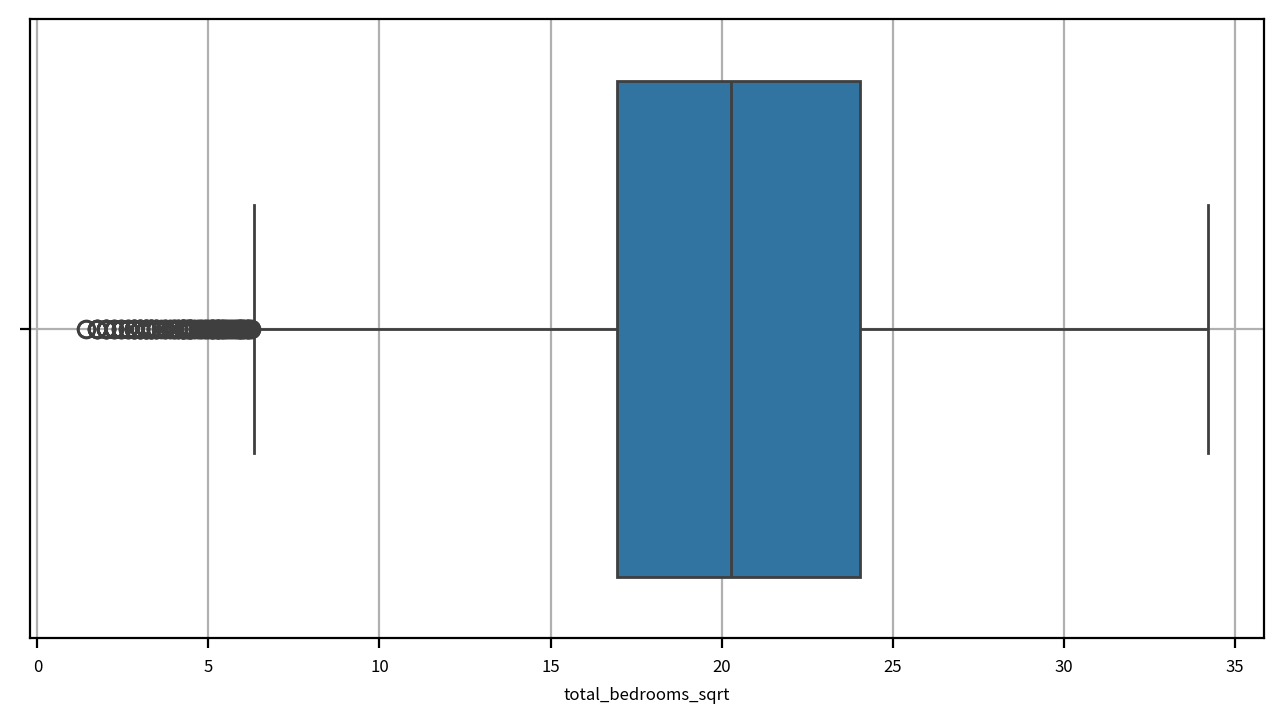

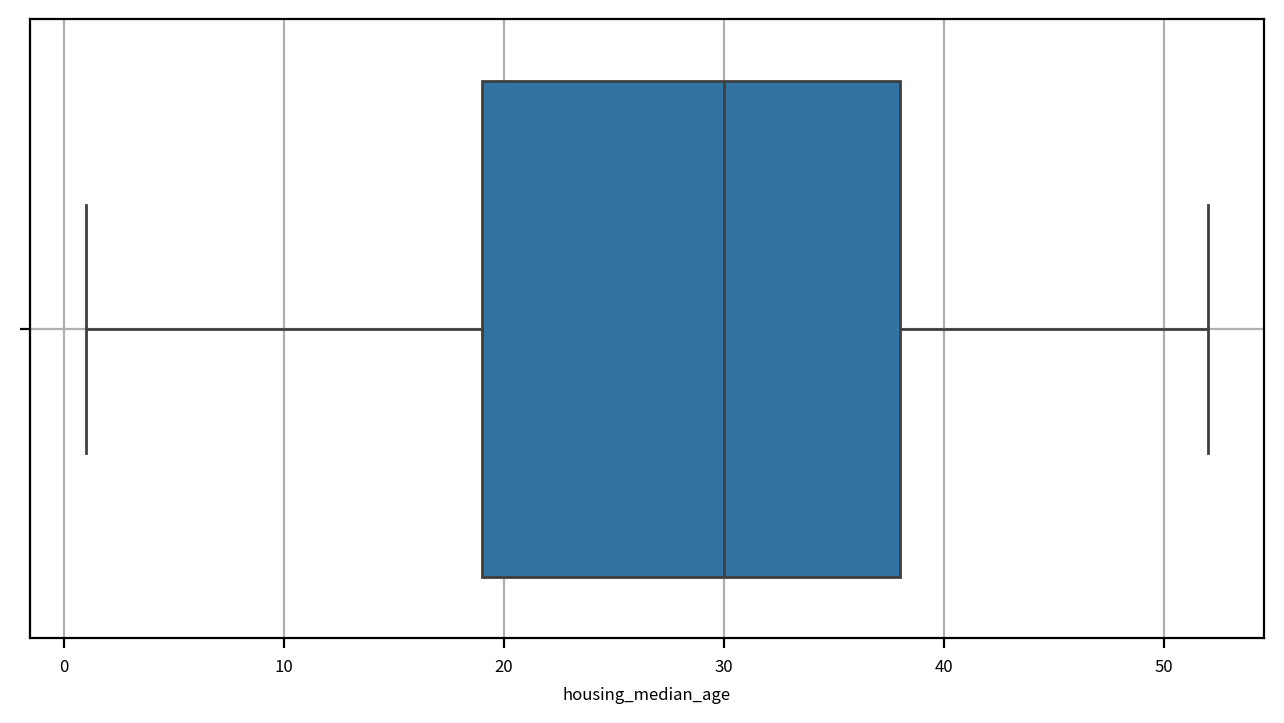

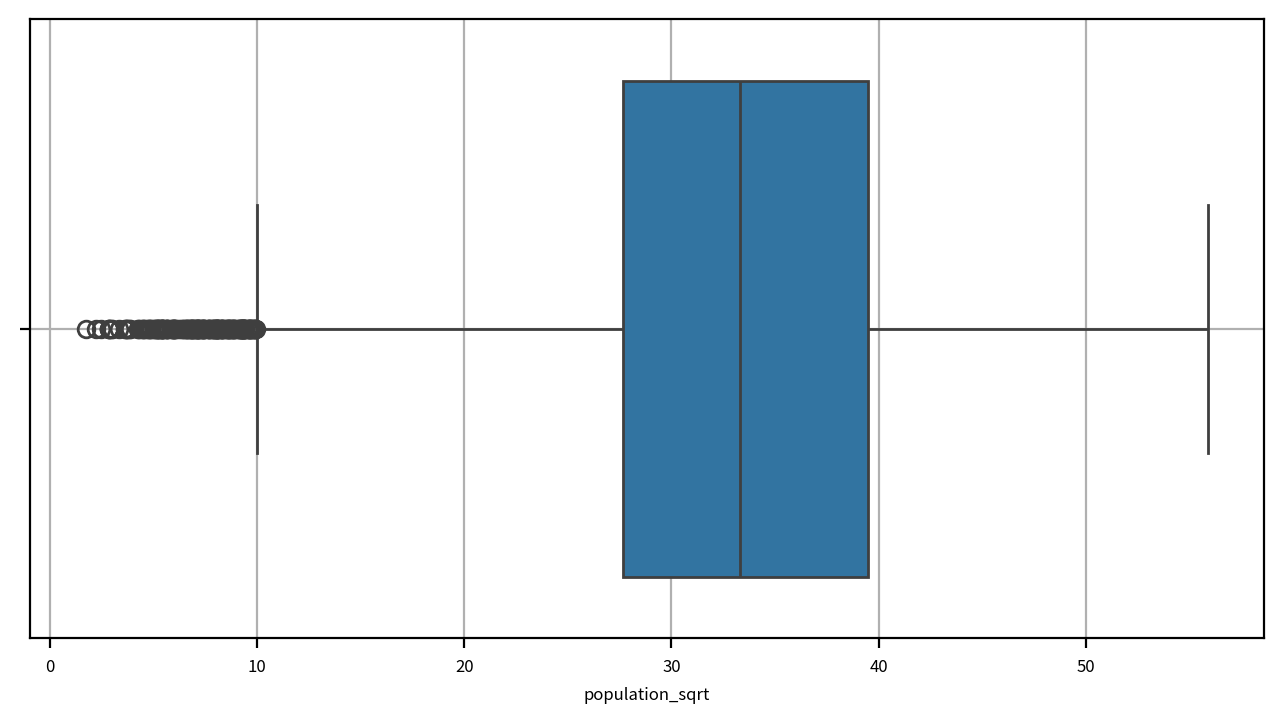

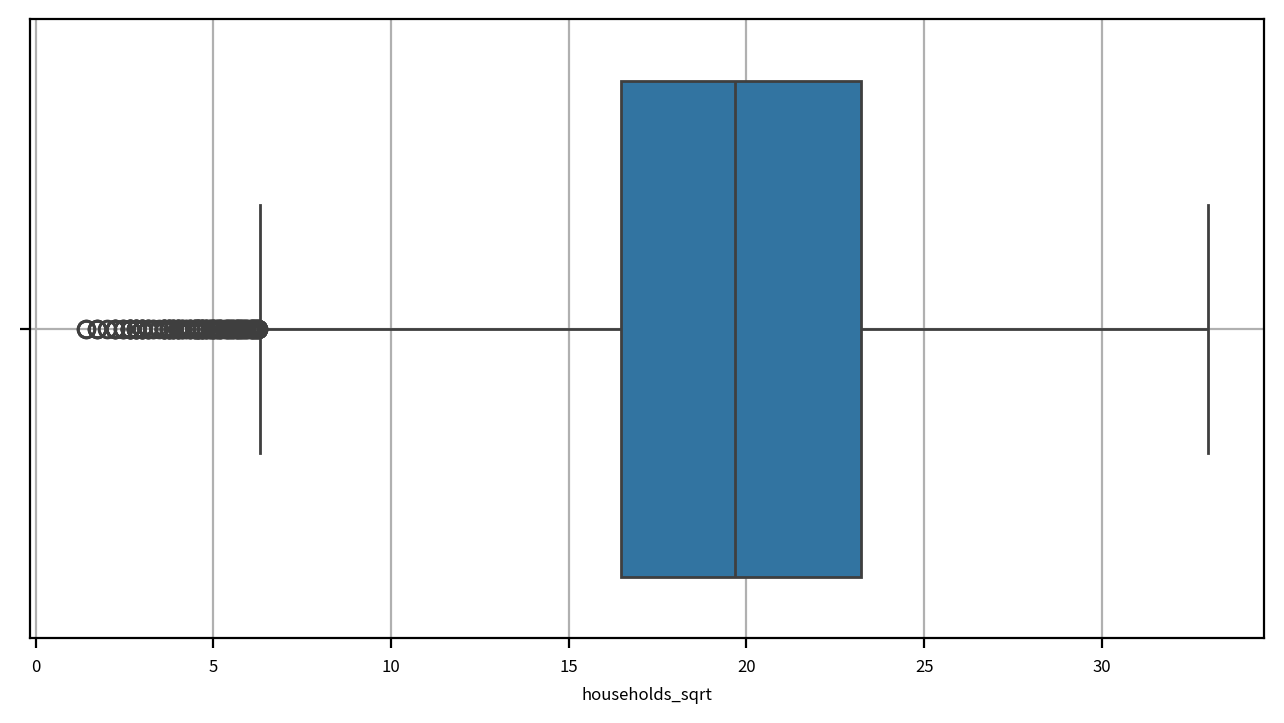

In [49]:
mylist2=['total_rooms_sqrt', 'total_bedrooms_sqrt', 'housing_median_age', 'population_sqrt', 'households_sqrt']
for i in mylist2:
    plot.hs_boxplot(df=df2[i], orient='h')

근데 이거 맨 위에 전처리 과정에서 한 거 아님? 😥

## 🎯미션7~9. 소득과 다른 특성의 독립성 및 상관성 확인

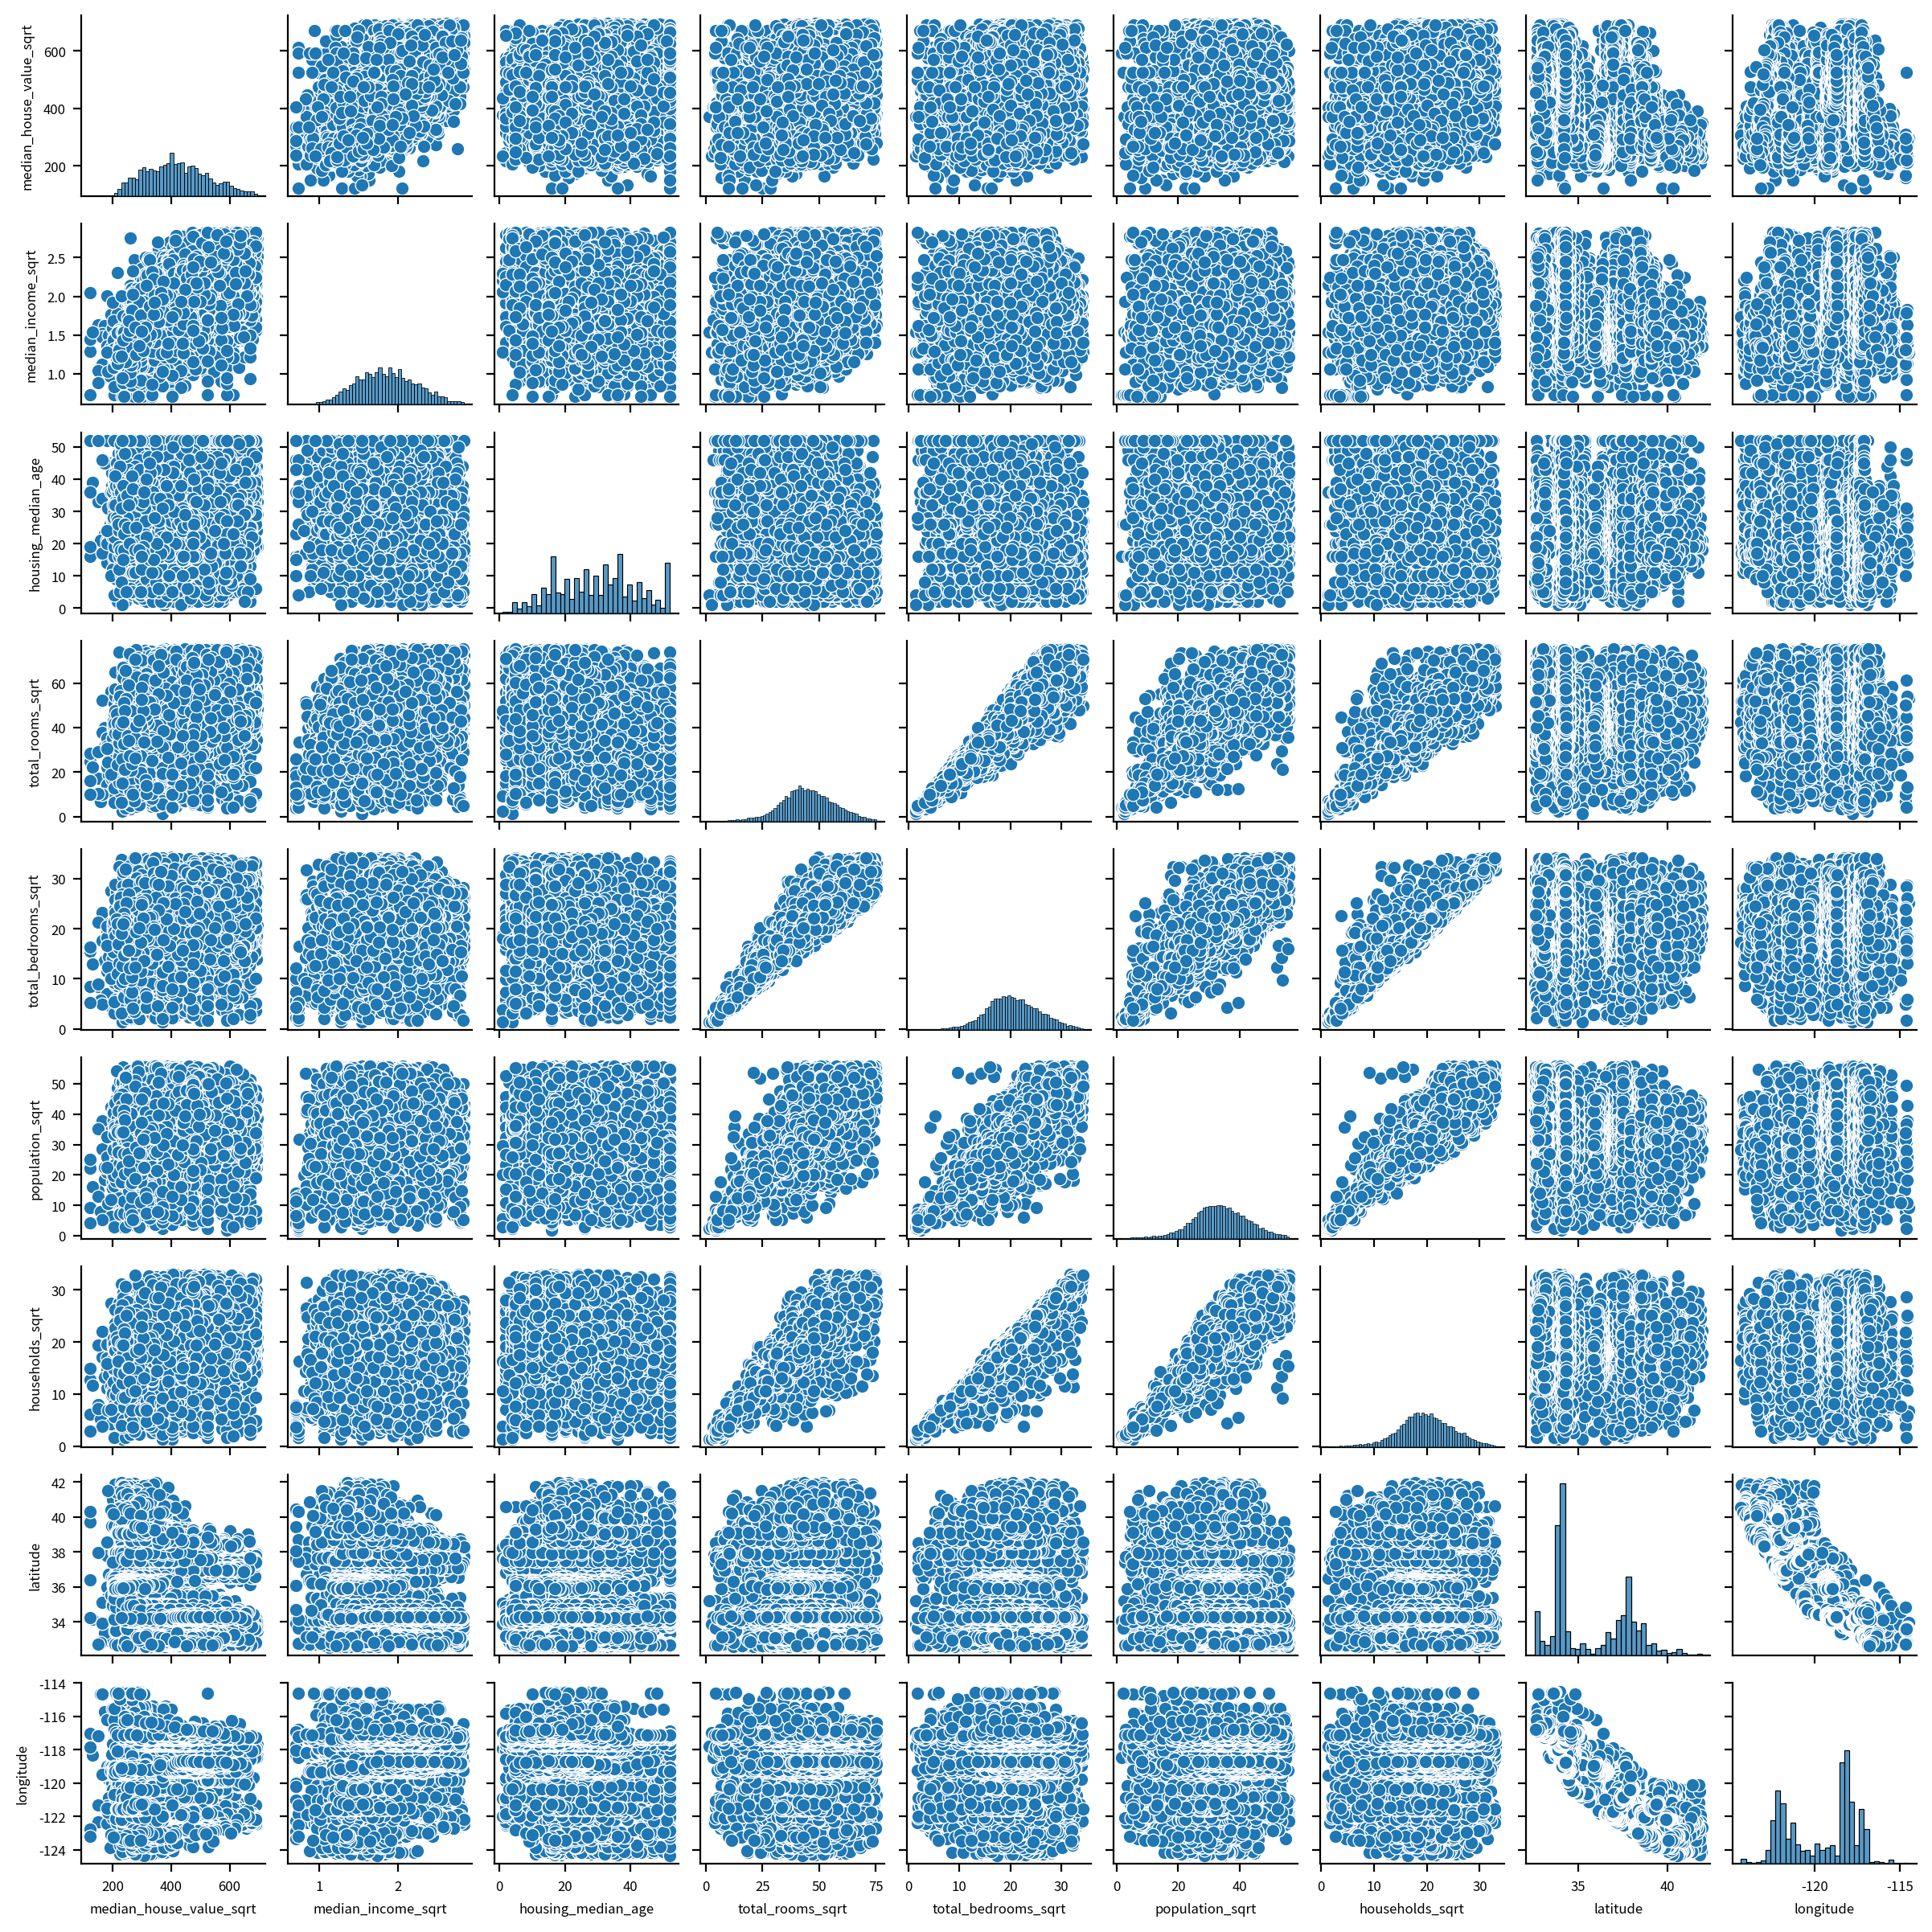

✅ 이상치 요약


,original_skew,log_skew,outliers(|z|>3)
median_house_value_sqrt,0.252556,-1.016488,0.0
median_income_sqrt,0.087332,-0.217533,0.0
housing_median_age,0.014592,-1.152424,0.0
total_rooms_sqrt,-0.158897,-1.832509,75.0
total_bedrooms_sqrt,-0.153247,-1.714369,76.0
population_sqrt,-0.181342,-1.792161,67.0
households_sqrt,-0.216828,-1.739417,79.0
latitude,0.427574,0.031380,0.0
longitude,-0.266561,-0.608663,0.0


🎈 상관 분석


,var_a,var_b,linearity,outlier_flag,chosen,corr,pval,significant,strength
0,median_house_value_sqrt,median_income_sqrt,False,False,spearman,0.645382,0.000000e+00,True,Strong
1,median_house_value_sqrt,housing_median_age,False,False,spearman,0.075025,3.455850e-23,True,Very Weak
2,median_house_value_sqrt,total_rooms_sqrt,False,True,spearman,0.200684,7.946019e-158,True,Weak
3,median_house_value_sqrt,total_bedrooms_sqrt,False,True,spearman,0.099378,1.654492e-39,True,Very Weak
4,median_house_value_sqrt,population_sqrt,False,True,spearman,0.018025,1.732378e-02,True,Very Weak
5,median_house_value_sqrt,households_sqrt,False,True,spearman,0.130920,1.703761e-67,True,Very Weak
6,median_house_value_sqrt,latitude,False,False,spearman,-0.178088,3.573011e-124,True,Very Weak
7,median_house_value_sqrt,longitude,False,False,spearman,-0.049601,5.667652e-11,True,Very Weak
8,median_income_sqrt,housing_median_age,False,False,spearman,-0.154025,5.294678e-93,True,Very Weak
9,median_income_sqrt,total_rooms_sqrt,False,True,spearman,0.275539,3.241439e-301,True,Weak


📊 상관 행렬


,households_sqrt,housing_median_age,latitude,longitude,median_house_value_sqrt,median_income_sqrt,population_sqrt,total_bedrooms_sqrt,total_rooms_sqrt
households_sqrt,1.000000,-0.196031,-0.070657,0.039594,0.130920,0.028487,0.880910,0.970917,0.893942
housing_median_age,-0.196031,1.000000,0.012988,-0.128739,0.075025,-0.154025,-0.190025,-0.225975,-0.287357
latitude,-0.070657,0.012988,1.000000,-0.881352,-0.178088,-0.088289,-0.136285,-0.046452,0.001902
longitude,0.039594,-0.128739,-0.881352,1.000000,-0.049601,-0.006529,0.116080,0.038547,0.014072
median_house_value_sqrt,0.130920,0.075025,-0.178088,-0.049601,1.000000,0.645382,0.018025,0.099378,0.200684
median_income_sqrt,0.028487,-0.154025,-0.088289,-0.006529,0.645382,1.000000,0.008326,-0.013925,0.275539
population_sqrt,0.880910,-0.190025,-0.136285,0.116080,0.018025,0.008326,1.000000,0.842689,0.782699
total_bedrooms_sqrt,0.970917,-0.225975,-0.046452,0.038547,0.099378,-0.013925,0.842689,1.000000,0.903078
total_rooms_sqrt,0.893942,-0.287357,0.001902,0.014072,0.200684,0.275539,0.782699,0.903078,1.000000


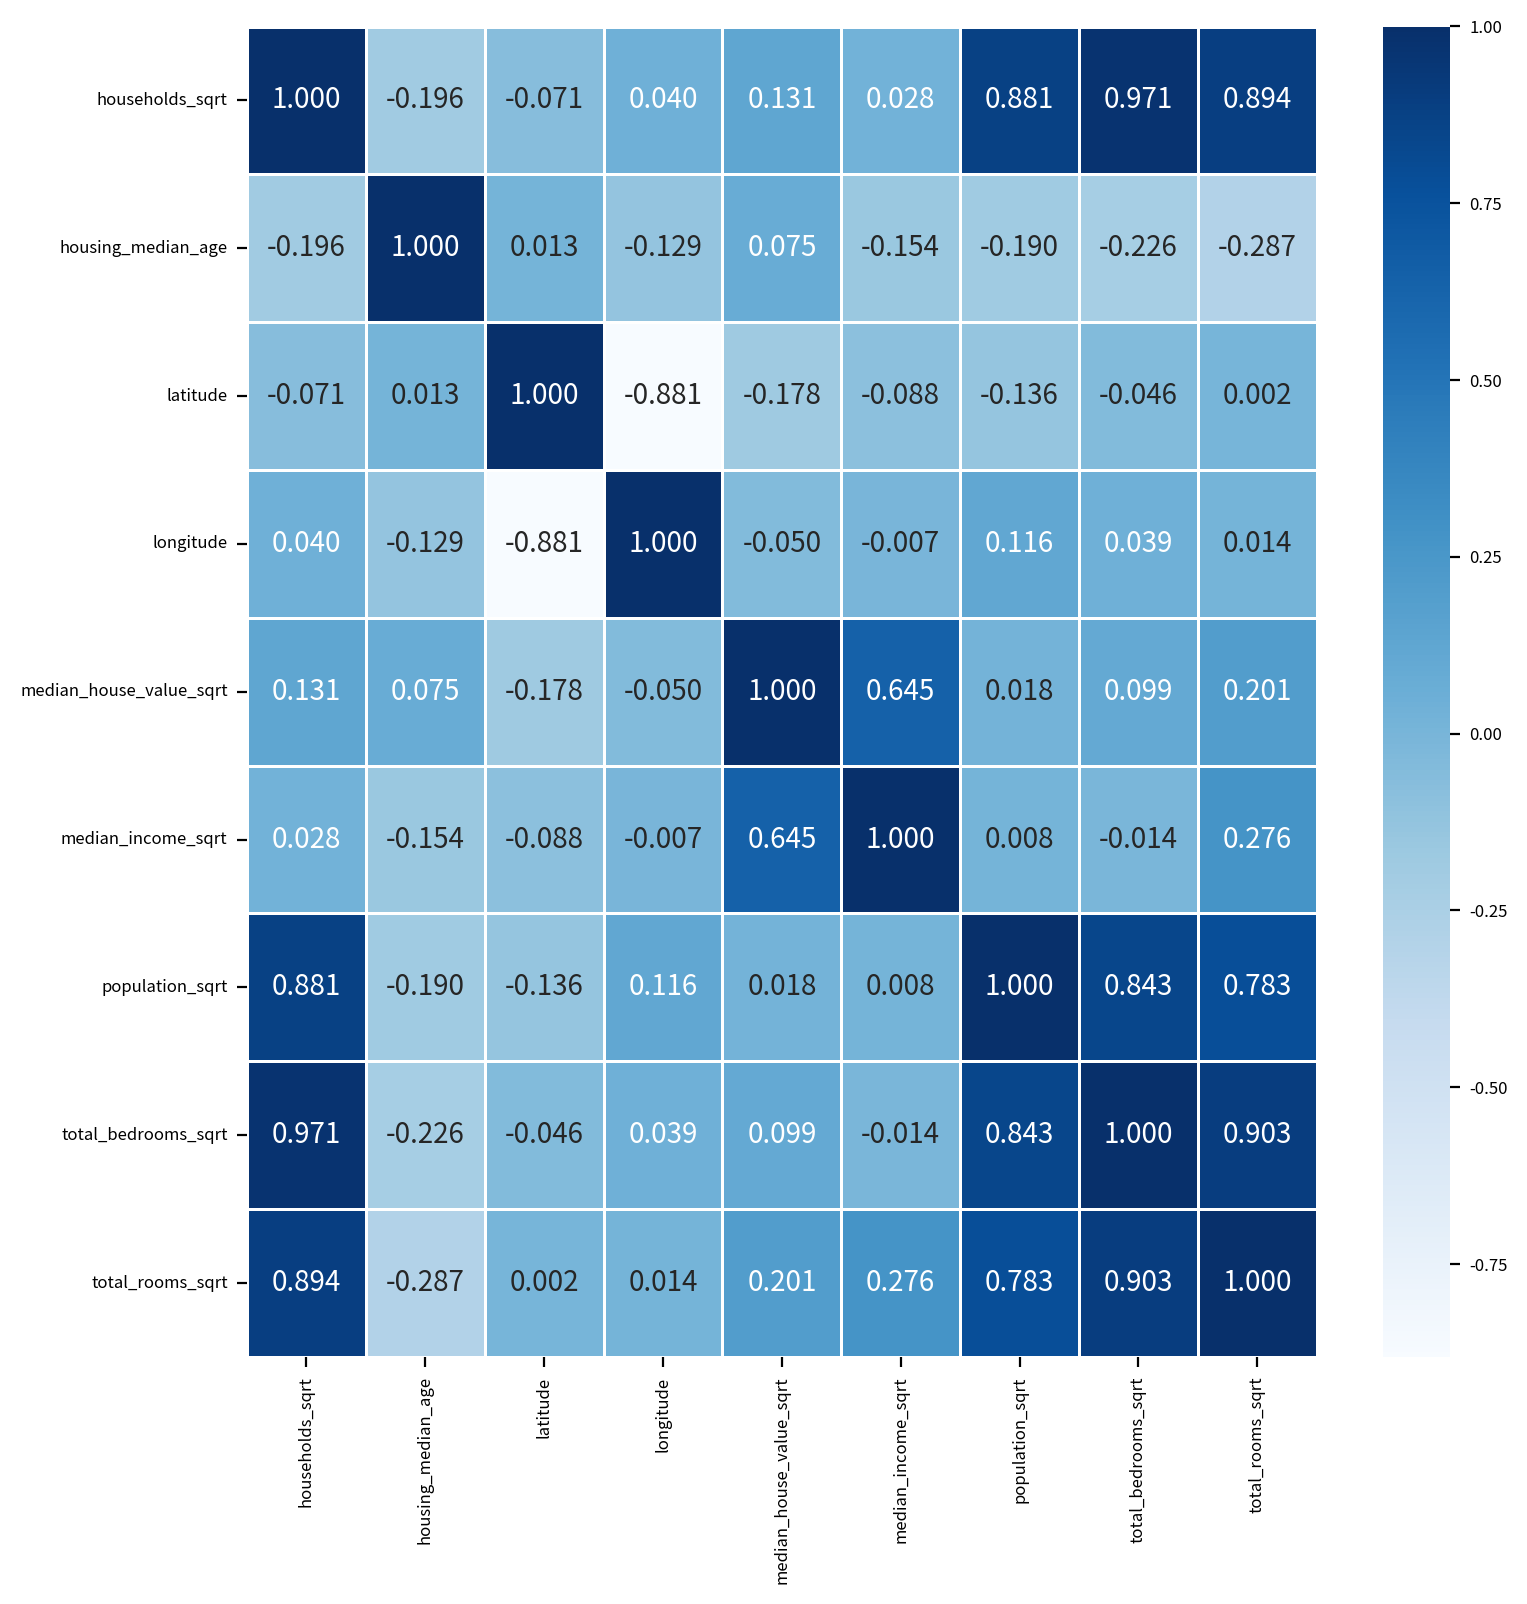

In [50]:
# 데이터 입력
df=df2.filter(['median_house_value_sqrt', 'median_income_sqrt', 'housing_median_age', 'total_rooms_sqrt', 'total_bedrooms_sqrt', 'population_sqrt', 'households_sqrt', 'latitude', 'longitude'])

# 패키지 참조
from hossam import load_data
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr
from itertools import combinations

# 그래프 초기화
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

# 페어플롯으로 형태 확인
width_px=2400
height_px=2400
figsize=(width_px/my_dpi, height_px/my_dpi)

g=sb.pairplot(df, diag_kind='hist')
g.fig.set_size_inches(figsize)
g.fig.set_dpi(my_dpi)
plt.tight_layout()
plt.show()
plt.close()

# 이상치 요약
print('='*50)
print('✅ 이상치 요약')
print('='*50)
skew_outlier={}
for col in df.columns:
    temp=df[col].dropna()
    skew_original=temp.skew()
    z_scores=zscore(temp)
    outlier_count=int(np.sum(np.abs(z_scores)>3))

    data_log=np.log1p(temp-temp.min()+1)
    skew_log=data_log.skew()
    skew_outlier[col]={
        'original_skew':skew_original,
        'log_skew':skew_log,
        'outliers(|z|>3)':outlier_count
    }
skew_outlier_df=DataFrame(skew_outlier).T
display(skew_outlier_df)

# 상관 분석
print('='*50)
print('🎈 상관 분석')
print('='*50)
rows=[]
for a, b in combinations(df.columns, 2):
    x=df[a]
    y=df[b]
    X=sm.add_constant(x)
    model=sm.OLS(y,X).fit()
    reset=linear_reset(model, power=2, use_f=True)
    linearity_ok=reset.pvalue>0.05
    a_flag=skew_outlier_df.loc[a, 'outliers(|z|>3)']>0
    b_flag=skew_outlier_df.loc[b, 'outliers(|z|>3)']>0
    outlier_flag=a_flag or b_flag
    if linearity_ok and not outlier_flag:
        chosen='pearson'
        corr, pval=pearsonr(x, y)
    else:
        chosen='spearman'
        corr, pval=spearmanr(x, y)
    significant=pval<=0.05
    abs_r=abs(corr)
    if abs_r>=0.80:
        strength='Very Strong'
    elif abs_r>=0.60:
        strength='Strong'
    elif abs_r>=0.40:
        strength='Medium'
    elif abs_r>=0.20:
        strength='Weak'
    else:
        strength='Very Weak'
    rows.append({
        'var_a':a,
        'var_b':b,
        'linearity':linearity_ok,
        'outlier_flag':outlier_flag,
        'chosen':chosen,
        'corr':corr,
        'pval':pval,
        'significant':significant,
        'strength':strength
    })
summary_df=DataFrame(rows)
display(summary_df)

# 상관 행렬
print('='*50)
print('📊 상관 행렬')
print('='*50)
vars=sorted(set(summary_df['var_a']).union(summary_df['var_b']))
corr_matrix=DataFrame(np.nan, index=vars, columns=vars)
for _, row in summary_df.iterrows():
    a, b, r = row['var_a'], row['var_b'], row['corr']
    corr_matrix.loc[a,b]=r
    corr_matrix.loc[b,a]=r
np.fill_diagonal(corr_matrix.values,1)
display(corr_matrix)

# 상관행렬 시각화
width_px=1600
height_px=1600
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.heatmap(data=corr_matrix, annot=True, fmt='0.3f', linewidth=0.5, cmap='Blues', annot_kws={'size':10})
plt.tight_layout()
plt.show()
plt.close()

주택 중위가격과 가장 높은 상관을 보이는 변수는 "구역의 중위 소득"이고, 그 다음으로는 "구역 내 모든 주택의 총 방 수"이다.  
다음으로 높은 상관을 가지는 변수는 "위도"와 "구역의 전체 가구 수"이다.  
따라서 이 4가지의 변수를 이용하여 회귀분석 모델을 만들어 볼 예정이다.  

또한 데이터 수집 시점, 지역 편향적인 특성, 측정 누락 등 수치적인 지표로 보기 힘든 요소들이 배제되어 있는 데이터이기 때문에, 높은 상관을 가진다고 하여 반드시 일어나는 <인과 관계>라고 바라보기에는 어려움이 있다.

## 🎯미션10~12. 주택 가격을 설명하는 회귀 모형 설계

📊 다중 선형 회귀
                               OLS Regression Results                              
Dep. Variable:     median_house_value_sqrt   R-squared:                       0.472
Model:                                 OLS   Adj. R-squared:                  0.472
Method:                      Least Squares   F-statistic:                     3900.
Date:                     Tue, 30 Dec 2025   Prob (F-statistic):               0.00
Time:                             16:17:04   Log-Likelihood:            -1.0065e+05
No. Observations:                    17431   AIC:                         2.013e+05
Df Residuals:                        17426   BIC:                         2.014e+05
Df Model:                                4                                         
Covariance Type:                 nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

,종속변수,독립변수,B,표준오차,Beta,t,p-value,공차,vif
0,median_house_value_sqrt,median_income_sqrt,177.6803,1.616,0.634791,109.918***,0.0,0.100157,9.984281
1,median_house_value_sqrt,households_sqrt,2.1460,0.118,0.105079,18.195***,0.0,0.100157,9.984281


median_house_value_sqrt에 대하여 median_income_sqrt,households_sqrt로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다(F(2,17428)=6307., p <= 0.05).
📕 선형성 검정
RESET F-statistic: 174.4843
p-value: 0.0000
선형성/기능형 위배 가능성이 있음 (5% 유의수준)


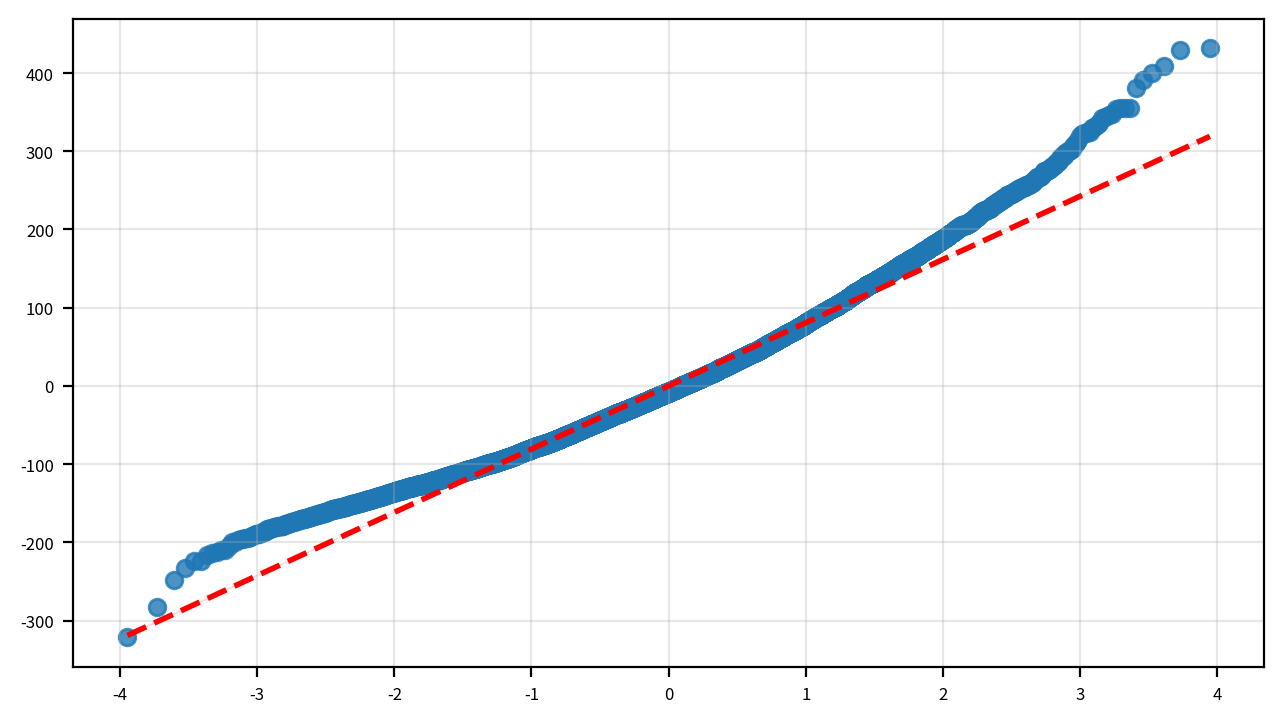

루트 1MSE 구간에 포함된 잔차 비율: 100.00%
루트 2MSE 구간에 포함된 잔차 비율: 100.00%
루트 3MSE 구간에 포함된 잔차 비율: 100.00%


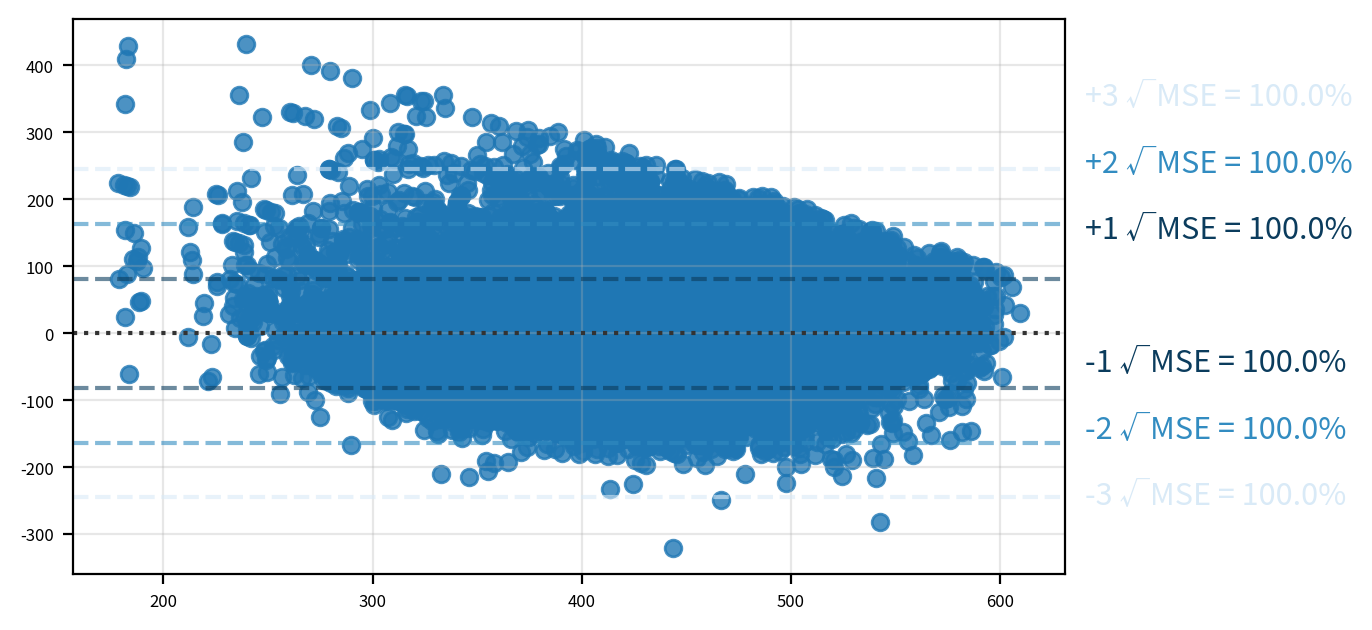

🎯 잔차의 정규성, 등분산성, 독립성 검정
Anderson-Darling statistic: 76.0086, 5% 임계값: 0.7870
정규성 가정 위배 가능성이 있음 (5% 유의수준)
Breusch-Pagan statistic: 52.755, p-value = 0.000
이분산성 존재(등분산 아님)
Durbin-Watson=0.636
잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)
🎓 최종 결과 보고
median_house_value_sqrt에 대하여 median_income_sqrt,households_sqrt로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 유의하다(F(2,17428)=6307., p <= 0.05).
median_income_sqrt의 회귀계수는 177.6803(p <= 0.05)로, median_house_value_sqrt에 대하여 유의미한 예측변인인 것으로 나타났다.
households_sqrt의 회귀계수는 2.1460(p <= 0.05)로, median_house_value_sqrt에 대하여 유의미한 예측변인인 것으로 나타났다.


In [51]:
# 데이터 입력
df=df2.copy()
yname='median_house_value_sqrt'
df=df[['median_house_value_sqrt', 'median_income_sqrt', 'total_rooms_sqrt', 'latitude', 'households_sqrt']]

# 패키지 참조
from matplotlib import pyplot as plt
from matplotlib import font_manager as fm
import seaborn as sb
import numpy as np
import pandas as pd
from pandas import DataFrame
import statsmodels.api as sm
from statsmodels.stats.diagnostic import linear_reset
from scipy.stats import zscore, pearsonr, spearmanr, probplot, shapiro, kstest, anderson
from statsmodels.formula.api import ols
from statsmodels.stats.api import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor

# 그래프 초기화
my_dpi=200
font_path='../NotoSansKR-Regular.ttf'
fm.fontManager.addfont(font_path)
font_prop=fm.FontProperties(fname=font_path)
font_name=font_prop.get_name()
plt.rcParams['font.family']=font_name
plt.rcParams['font.size']=6
plt.rcParams['axes.unicode_minus']=False

# 다중선형회귀
df=pd.get_dummies(df, drop_first=True)
df=df.astype(float)
x=df.drop(yname, axis=1)
y=df[yname]
x_input=sm.add_constant(x)
fit=sm.OLS(y, x_input).fit()
tbl=fit.summary()
print('='*50)
print('📊 다중 선형 회귀')
print('='*50)
print(tbl)

def ols_report(tbl, data):
    xnames=[n for n in fit.model.exog_names if n!='const']
    indi_df=data.filter(xnames)
    variables=[]
    for i, v in enumerate(tbl.tables[1].data):
        name=v[0].strip()
        if name not in xnames:
            continue
        j=list(indi_df.columns).index(name)
        vif=variance_inflation_factor(indi_df,j)

        p=float(v[4].strip())
        stars=lambda p: (
            '***' if p<0.001 else
            '**' if p<0.01 else
            '*' if p<0.05 else
            ''
        )

        variables.append({
            '종속변수':yname,
            '독립변수':name,
            'B':v[1].strip(),
            '표준오차':v[2].strip(),
            'Beta':float(fit.params[name])*(data[name].std(ddof=1)/data[yname].std(ddof=1)),
            't':'%s%s'%(v[3].strip(), stars(p)),
            'p-value':p,
            '공차':1/vif,
            'vif':vif
        })

    rdf=DataFrame(variables)

    result_dict={}
    for i in [0,2]:
        for item in tbl.tables[i].data:
            n=len(item)
            for j in range(0, n, 2):
                key=item[j].strip()[:-1]
                value=item[j+1].strip()
                if not key or not value:
                    continue
                result_dict[key]=value
    
    result_report=f'R({result_dict['R-squared']}), R²({result_dict['Adj. R-squared']}), F({result_dict['F-statistic']}), 유의확률({result_dict['Prob (F-statistic)']}), Durbin-Watson({result_dict['Durbin-Watson']})'

    tpl='%s에 대하여 %s로 예측하는 회귀분석을 실시한 결과, 이 회귀모형은 통계적으로 %s(F(%s,%s)=%s, p %s 0.05).'
    model_report=tpl%(
        rdf['종속변수'][0],
        ','.join(list(rdf['독립변수'])),
        '유의하다' if float(result_dict['Prob (F-statistic)'])<=0.05 else '유의하지 않다',
        result_dict['Df Model'],
        result_dict['Df Residuals'],
        result_dict['F-statistic'],
        '<=' if float(result_dict['Prob (F-statistic)'])<=0.05 else '>'
    )

    variable_reports=[]
    s='%s의 회귀계수는 %s(p %s 0.05)로, %s에 대하여 %s 예측변인인 것으로 나타났다.'

    for i in rdf.index:
        row=rdf.iloc[i]
        variable_reports.append(s%(row['독립변수'],
                                   row['B'],
                                   '<=' if float(row['p-value'])<0.05 else '>',
                                   row['종속변수'],
                                   '유의미한' if float(row['p-value'])<0.05 else '유의하지 않은'))
        
    return rdf, result_report, model_report, variable_reports

while True:
    rdf, r, m, v=ols_report(tbl, df)
    if rdf['vif'].max()>=10:
        df=df.drop(rdf[rdf['vif']==rdf['vif'].max()]['독립변수'], axis=1)
        x=df.drop(yname, axis=1)
        y=df[yname]
        x_input=sm.add_constant(x)
        fit=sm.OLS(y, x_input).fit()
        tbl=fit.summary()
    else:
        break

# p-value 무효값 제외
xnames=list(rdf[rdf['p-value']>0.05]['독립변수'])
df=df.drop(xnames, axis=1)
x=df.drop(yname, axis=1)
y=df[yname]
x_input=sm.add_constant(x)
fit=sm.OLS(y, x_input).fit()
tbl=fit.summary()
rdf, r, m, v=ols_report(tbl, df)
print('='*50)
print('✅ 분석 결과')
print('='*50)
display(rdf)
print(m)

# 잔차 검정
print('='*50)
print('📕 선형성 검정')
print('='*50)
reset_res=linear_reset(fit, power=2, use_f=True)
print(f'RESET F-statistic: {reset_res.fvalue:.4f}')
print(f'p-value: {reset_res.pvalue:.4f}')
if reset_res.pvalue<0.05:
    print('선형성/기능형 위배 가능성이 있음 (5% 유의수준)')
else:
    print('선형성 가정 위배 근거 없음 (5% 유의수준)')

(x,y),_=probplot(fit.resid)
width_px=1280
height_px=720
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.regplot(x=x, y=y, line_kws={'color':'red', 'linestyle':'--', 'linewidth':2})
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
plt.close()

r=fit.resid
mse_sq=fit.mse_resid
mse_root=np.sqrt(mse_sq)
colors=['#0B3C5D', '#328CC1', '#D9EAF7']
r1=r[(r>-mse_sq)&(r<mse_sq)].count()/r.count()*100
r2=r[(r>-2*mse_sq)&(r<2*mse_sq)].count()/r.count()*100
r3=r[(r>-3*mse_sq)&(r<3*mse_sq)].count()/r.count()*100
mse_r=[r1,r2,r3]
print(f'루트 1MSE 구간에 포함된 잔차 비율: {r1:.2f}%')
print(f'루트 2MSE 구간에 포함된 잔차 비율: {r2:.2f}%')
print(f'루트 3MSE 구간에 포함된 잔차 비율: {r3:.2f}%')
width_px=1280
height_px=720
rows=1
cols=1
figsize=(width_px/my_dpi, height_px/my_dpi)
fig, ax=plt.subplots(rows, cols, figsize=figsize, dpi=my_dpi)
sb.residplot(x=fit.fittedvalues, y=fit.resid)
ax.grid(True, alpha=0.3)
for i, c in enumerate(colors):
    k=i+1
    y_pos=k*mse_root
    ax.axhline(y=y_pos, color=c, linestyle='--', alpha=0.6)
    ax.axhline(y=-y_pos, color=c, linestyle='--', alpha=0.6)
    ax.text(x=1.02, y=0.5+0.12*k,
            s=f'+{k} √MSE = {mse_r[i]}%',
            transform=ax.transAxes,
            ha='left', va='center', fontsize=11, color=c)
    ax.text(x=1.02, y=0.5-0.12*k,
            s=f'-{k} √MSE = {mse_r[i]}%',
            transform=ax.transAxes,
            ha='left', va='center', fontsize=11, color=c)
plt.show()
plt.close()

# 잔차의 정규성, 등분산성, 독립성 검정
print('='*50)
print('🎯 잔차의 정규성, 등분산성, 독립성 검정')
print('='*50)
if len(origin)<5000:
    method='Shapiro-Wilk'
    s, p=shapiro(fit.resid)
    print(f'{method} statistic: {s:.4f}, p-value: {p:.4f}')
    violated=p<0.05
else:
    method='Anderson-Darling'
    ad_res=anderson(fit.resid, dist='norm')
    crit_levels=ad_res.significance_level.tolist()
    crit_values=ad_res.critical_values.tolist()
    crit_5=crit_values[crit_levels.index(5.0)] if 5.0 in crit_levels else None
    print(f'{method} statistic: {ad_res.statistic:.4f}, 5% 임계값: {crit_5:.4f}')
    violated=crit_5 is not None and ad_res.statistic>crit_5
print('정규성 가정 위배 가능성이 있음 (5% 유의수준)' if violated else '정규성 가정 위배 근거 없음 (5% 유의수준)')

names=['LM Statistic', 'LM p-value', 'F Statistic', 'F p-value']
bp_test=het_breuschpagan(fit.resid, fit.model.exog)
bp=DataFrame(bp_test, index=names, columns=['value'])
p_bp=bp.loc['F p-value', 'value']
print(f'Breusch-Pagan statistic: {bp.loc['F Statistic', 'value']:.3f}, p-value = {p_bp:.3f}')
print(f'{'이분산성 존재(등분산 아님)' if p_bp<=0.05 else '등분산성 만족'}')

dw=durbin_watson(fit.resid)
if 1.5<=dw<=2.5:
    interpretation='잔차는 독립성을 만족함 (자기상관 없음)'
elif dw<1.5:
    interpretation='잔차에 양(+)의 자기상관이 존재할 가능성 있음 (독립성 위반)'
else:
    interpretation='잔차에 음(-)의 자기상관이 존재할 가능성 있음 (독립성 위반)'
print(f'Durbin-Watson={dw:.3f}\n{interpretation}')

# 최종 결과 보고
print('='*50)
print('🎓 최종 결과 보고')
print('='*50)
print(m)
print('\n'.join(v))

## 🎯미션13. 예시 데이터를 통한 확인

In [52]:
my_house1={'median_income_sqrt':3, 'households_sqrt':16}

my_house2={'median_income_sqrt':3, 'households_sqrt':25}

x_new=DataFrame([my_house1])
x_new_input=sm.add_constant(x_new, has_constant='add')
myresult1=fit.predict(x_new_input)
print('구역의 중위 소득이 3만 달러이고 전체 가구 수가 16개인 구역의 주택 중위가격 :', myresult1.iloc[0])

y_new=DataFrame([my_house2])
y_new_input=sm.add_constant(y_new, has_constant='add')
myresult2=fit.predict(y_new_input)
print('구역의 중위 소득이 3만 달러이고 전체 가구 수가 25개인 구역의 주택 중위가격 :', myresult2.iloc[0])

구역의 중위 소득이 3만 달러이고 전체 가구 수가 16개인 구역의 주택 중위가격 : 615.0236606268927
구역의 중위 소득이 3만 달러이고 전체 가구 수가 25개인 구역의 주택 중위가격 : 634.3376074051031
